Criação de um ficheiro CSV com a informação relativa a nº de deglutiçoes, tempo do ficheiro .wav e duração do evento detetato

In [2]:
import os
import glob
import librosa
import scipy.signal
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

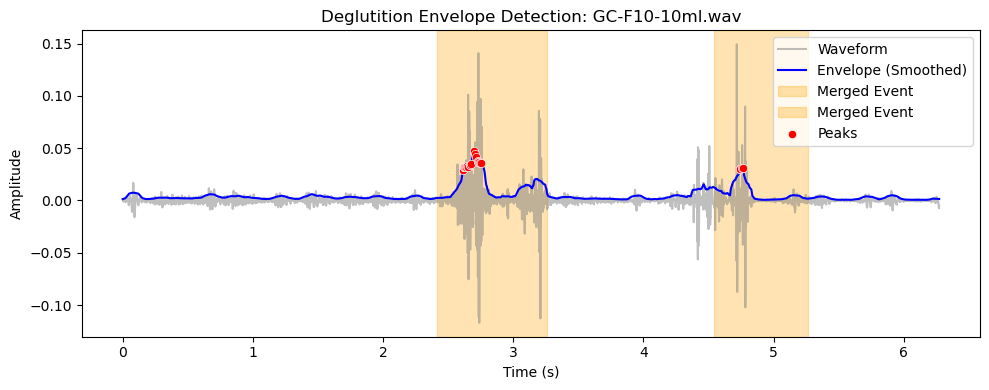

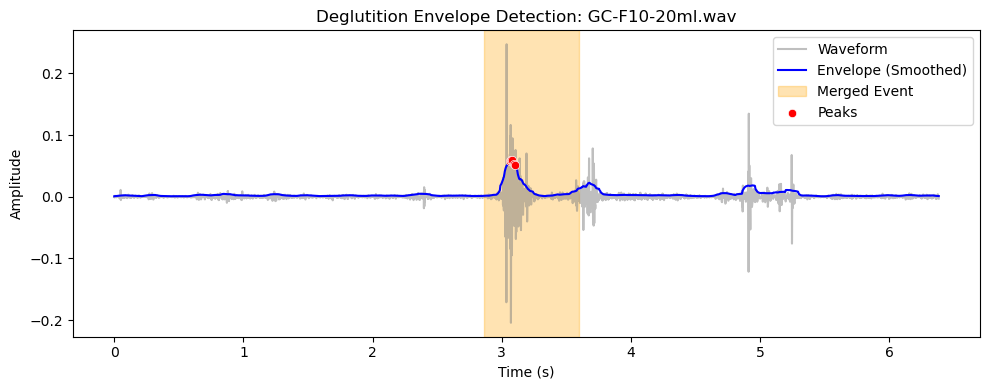

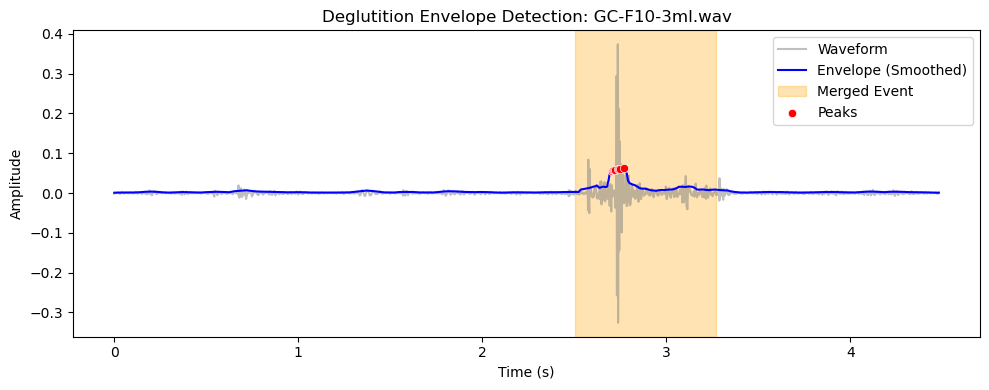

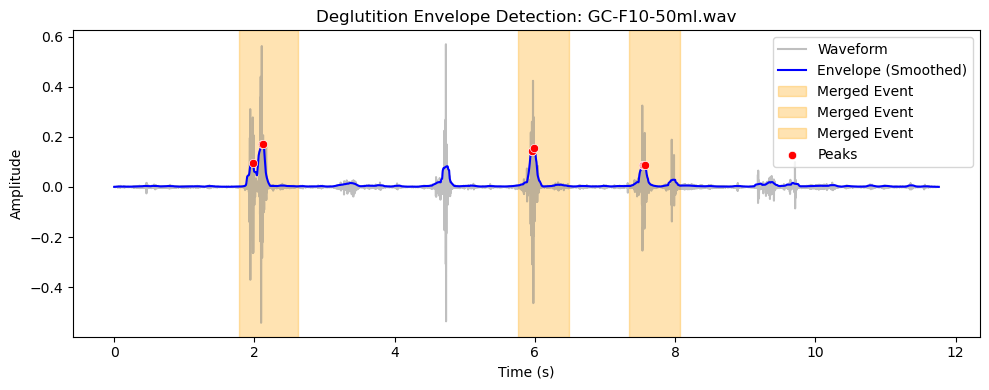

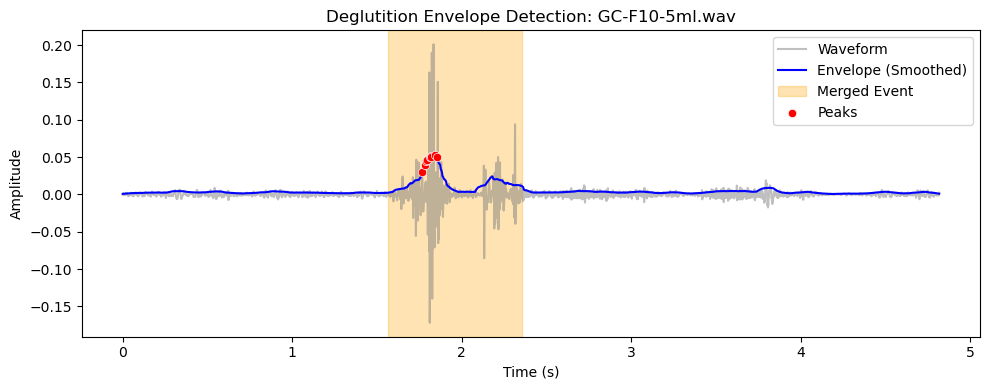

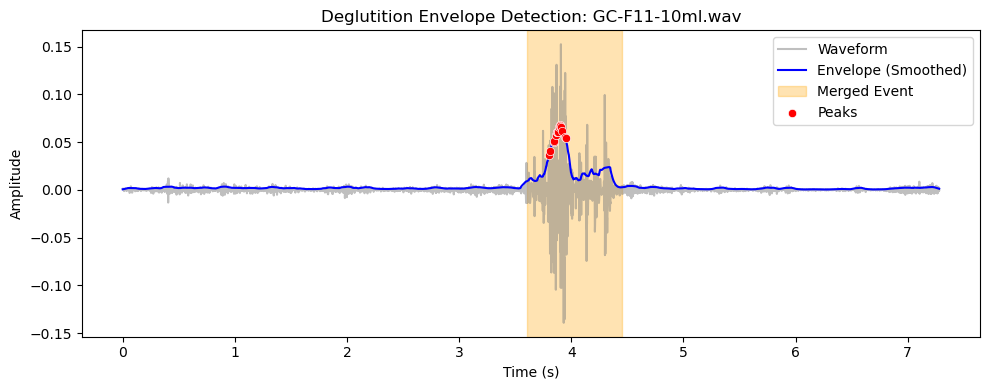

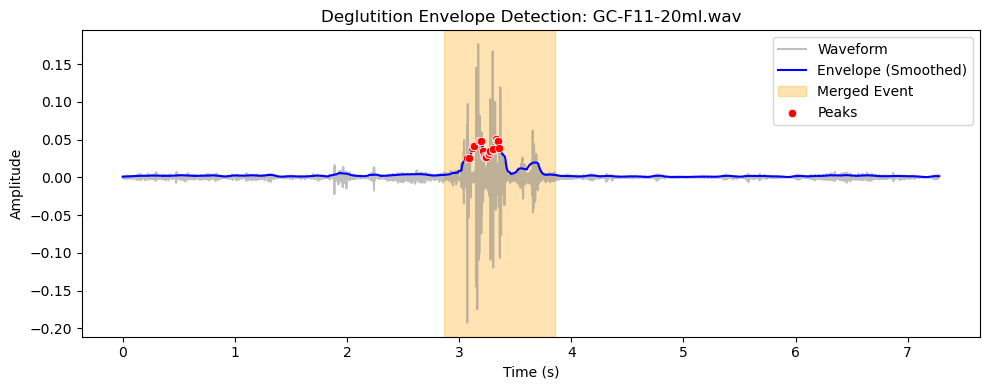

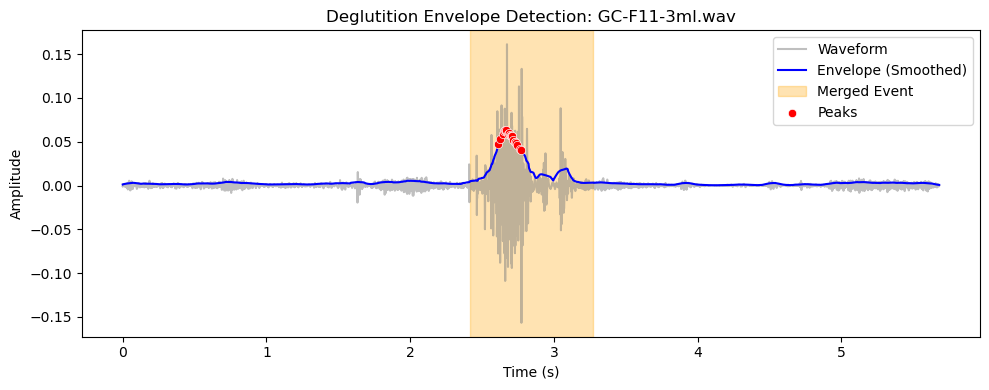

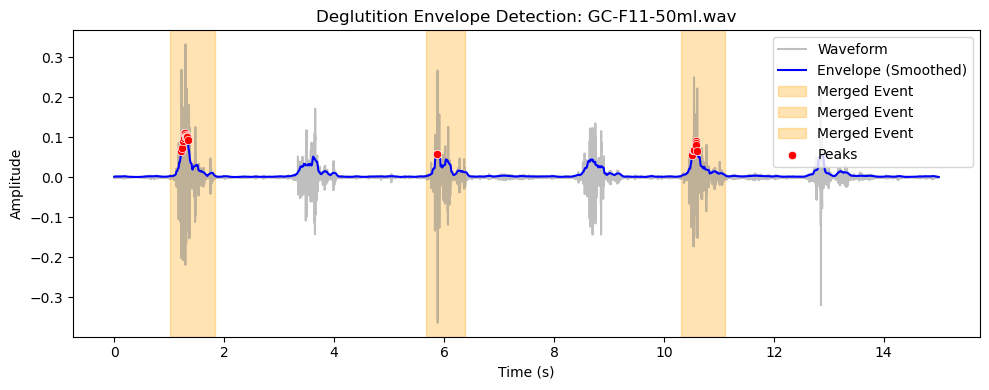

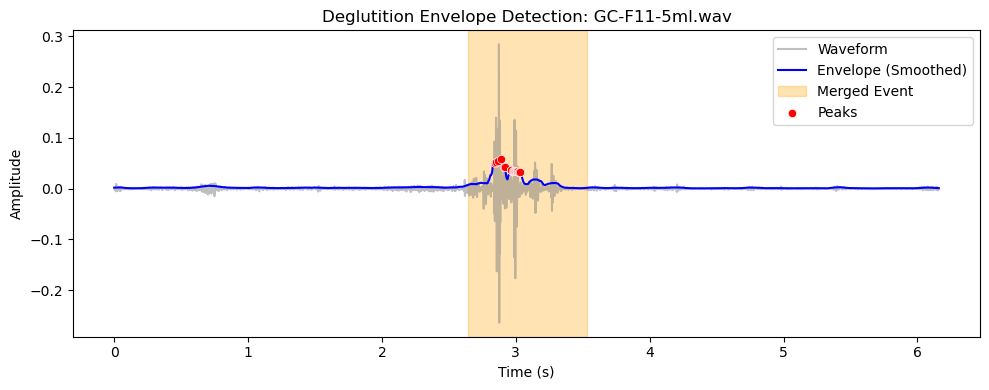

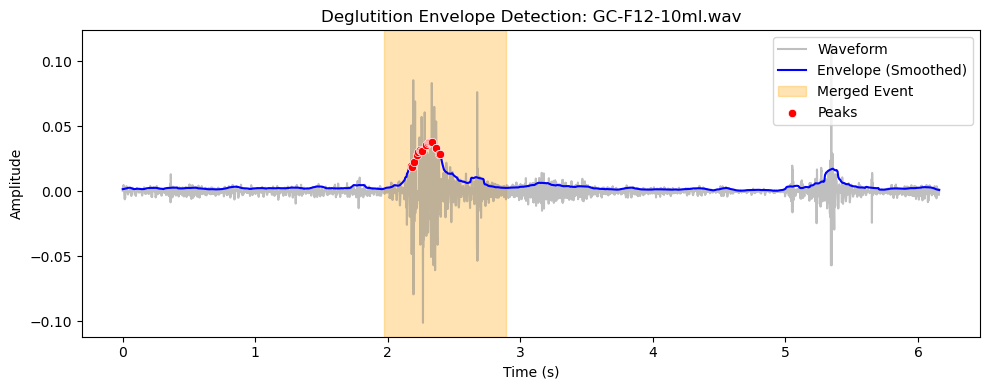

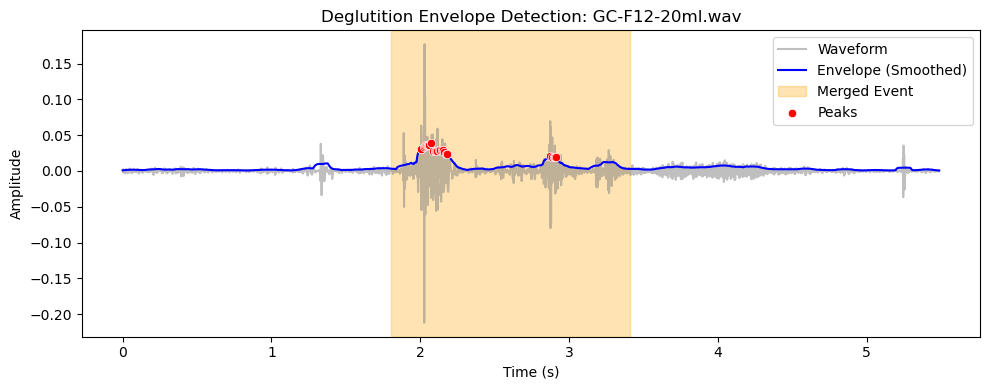

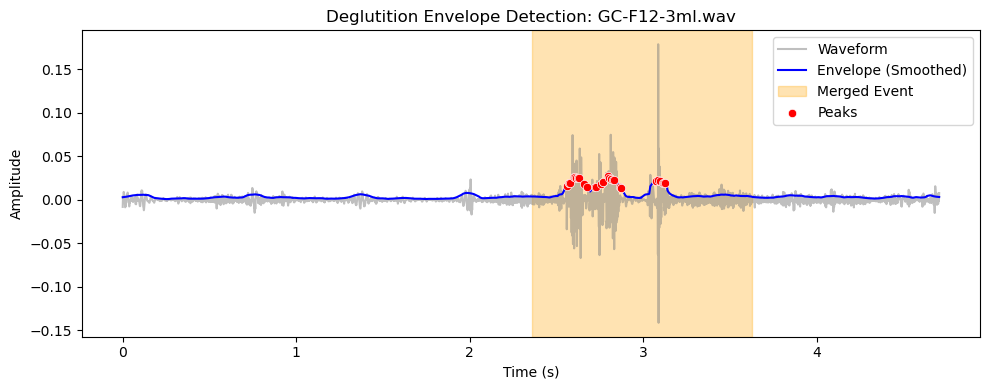

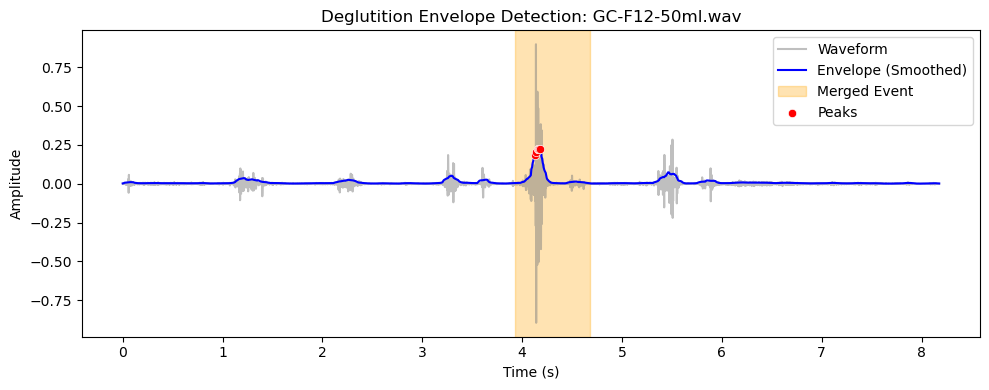

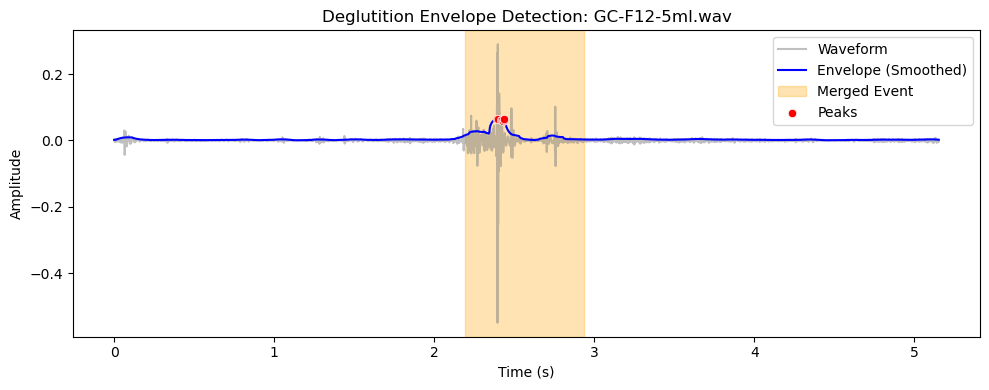

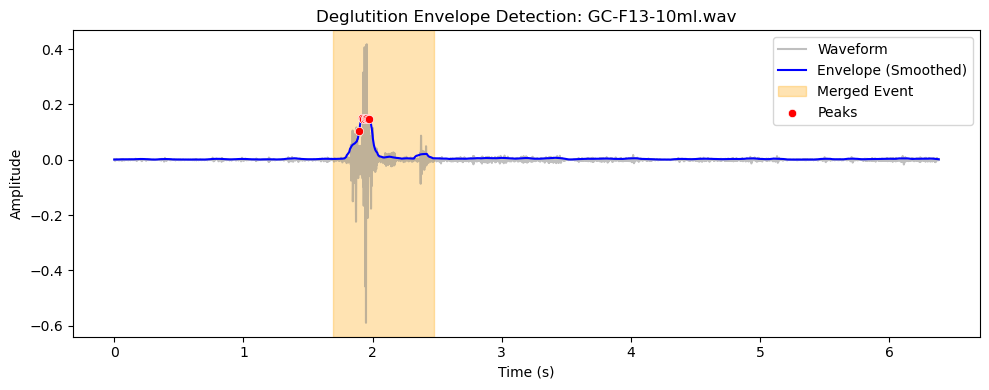

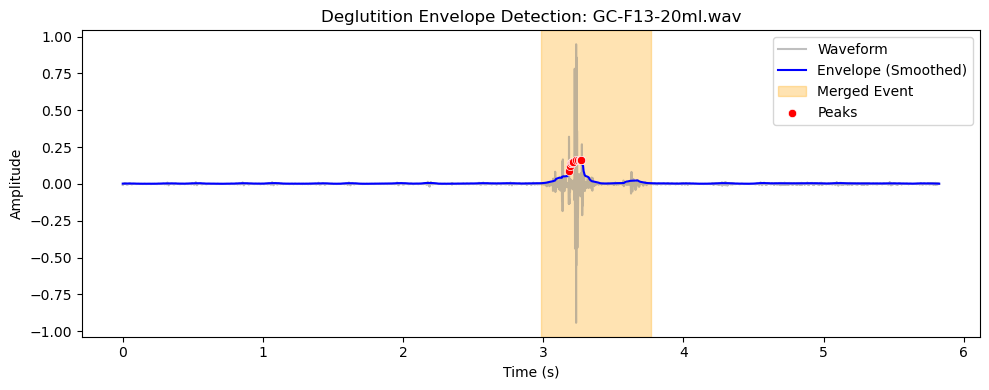

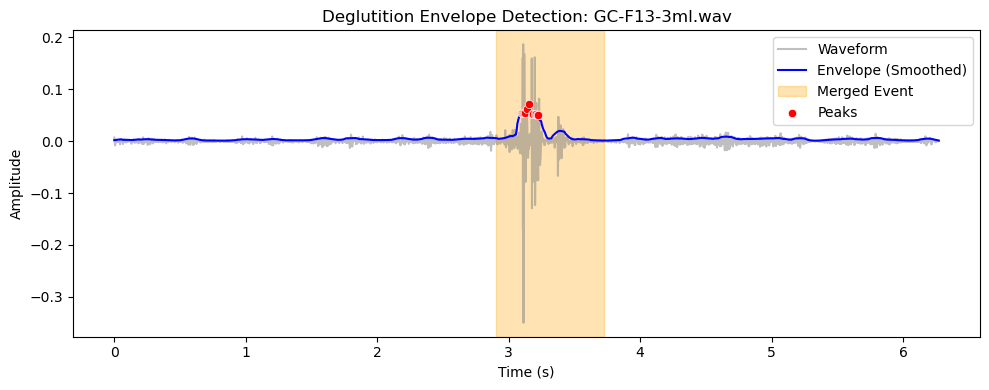

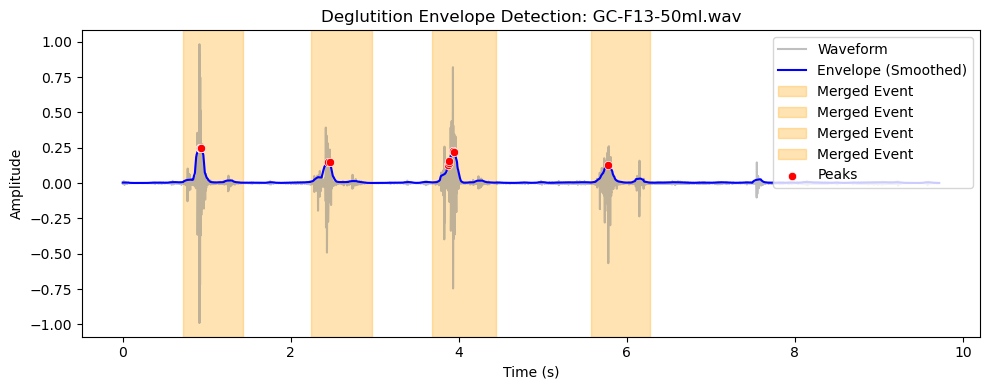

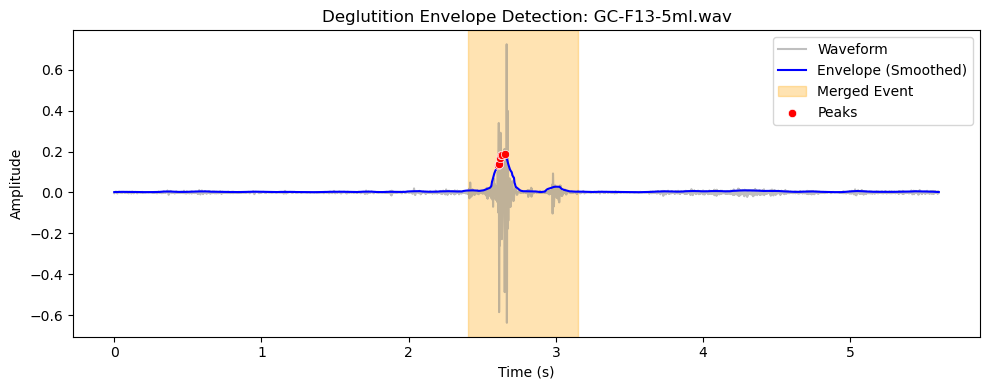

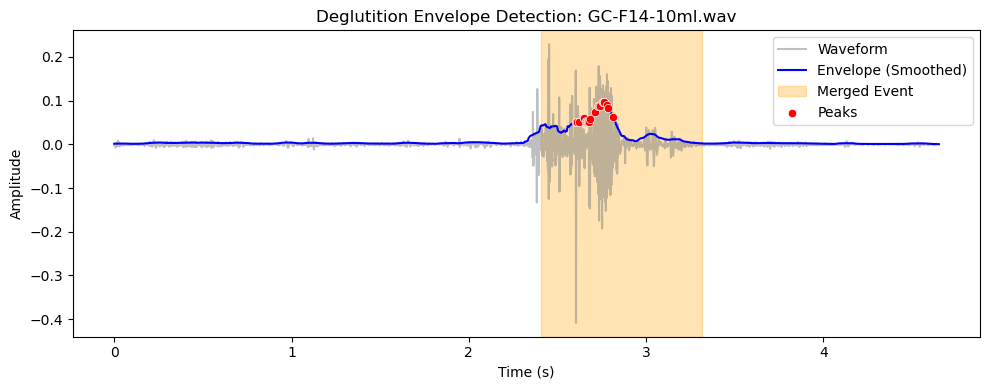

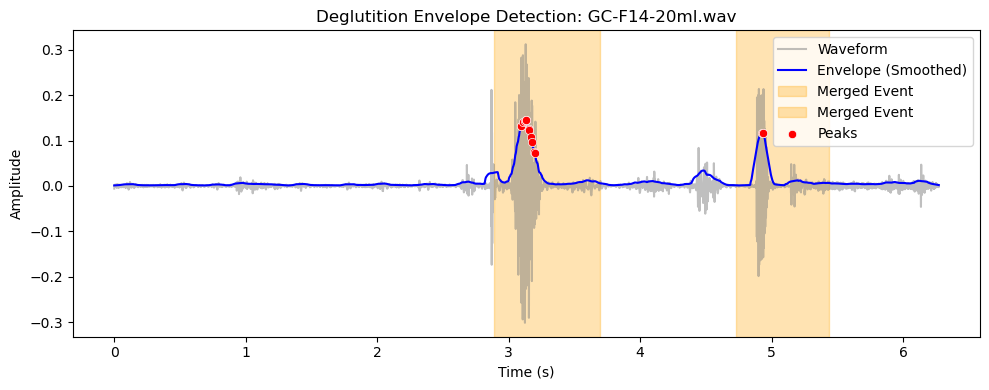

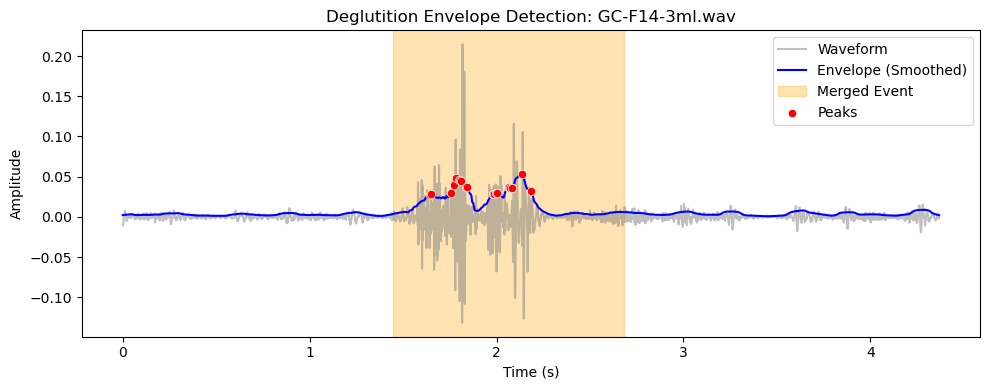

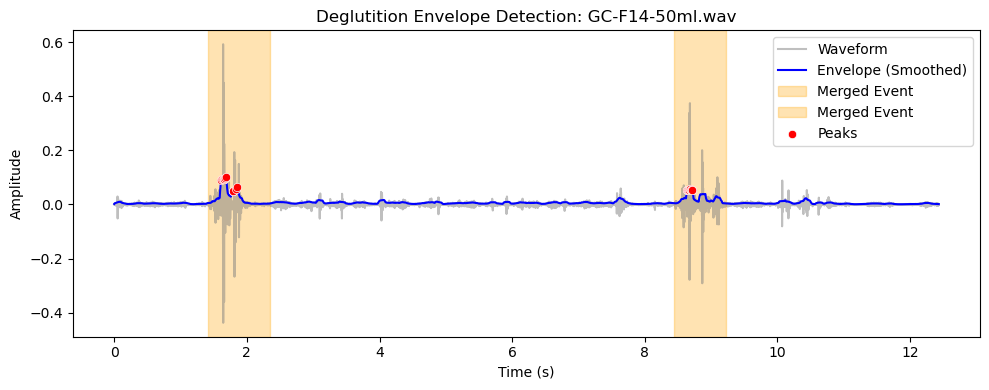

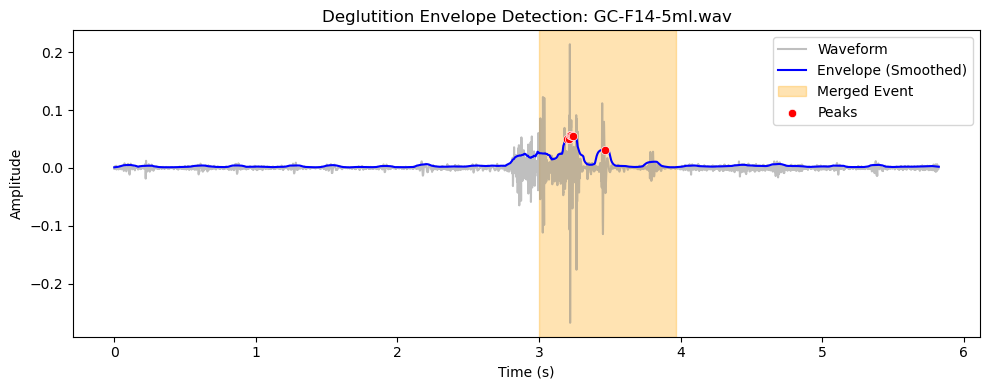

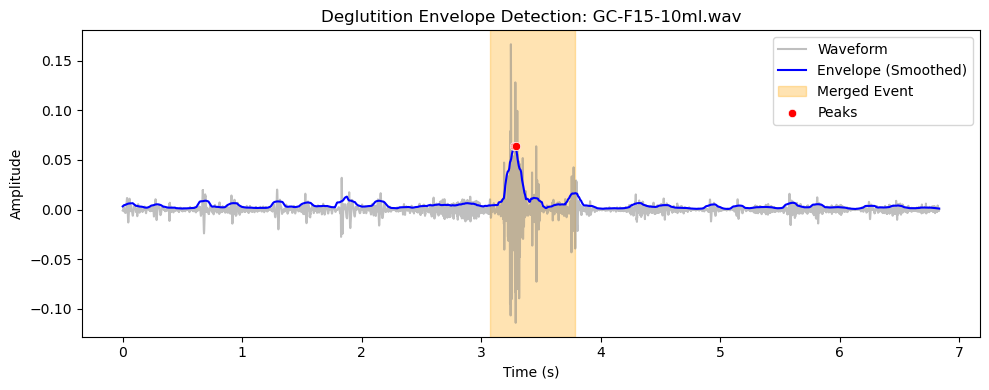

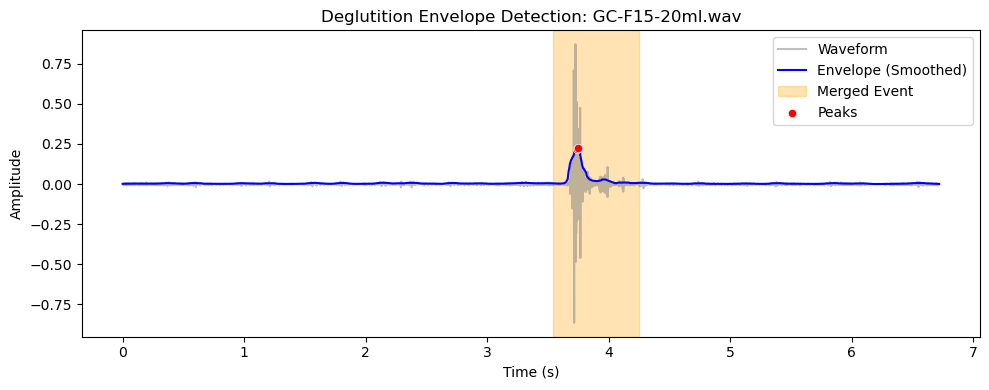

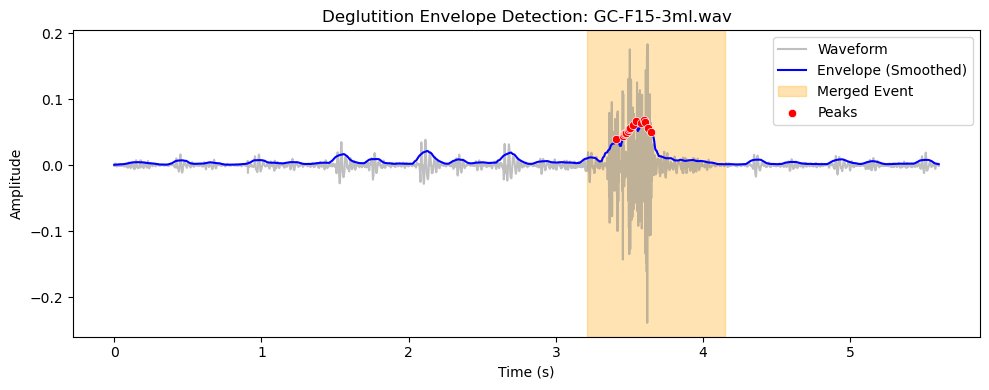

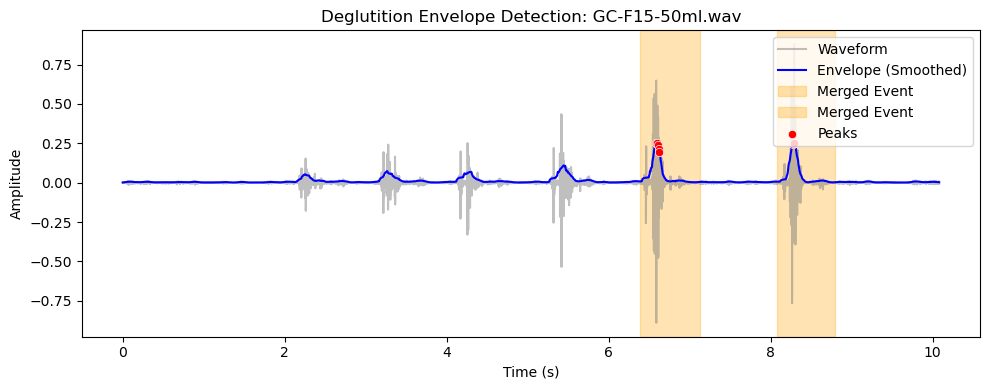

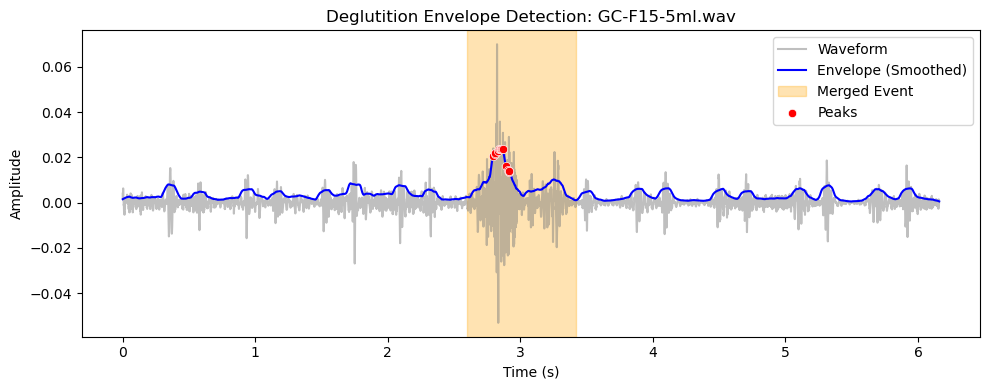

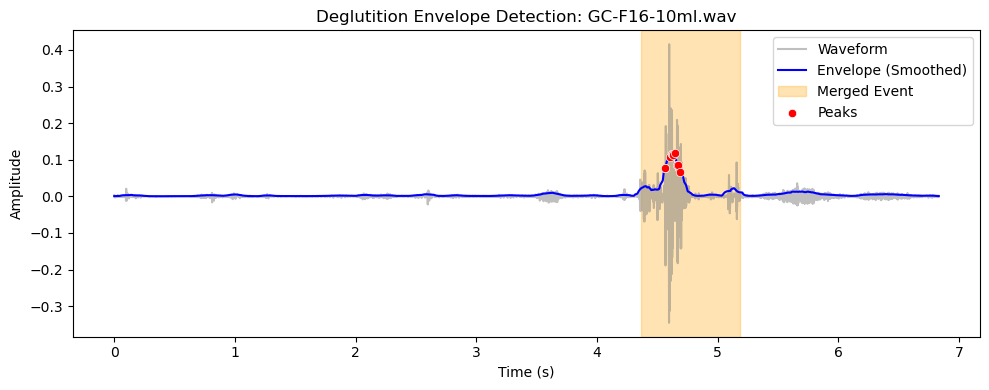

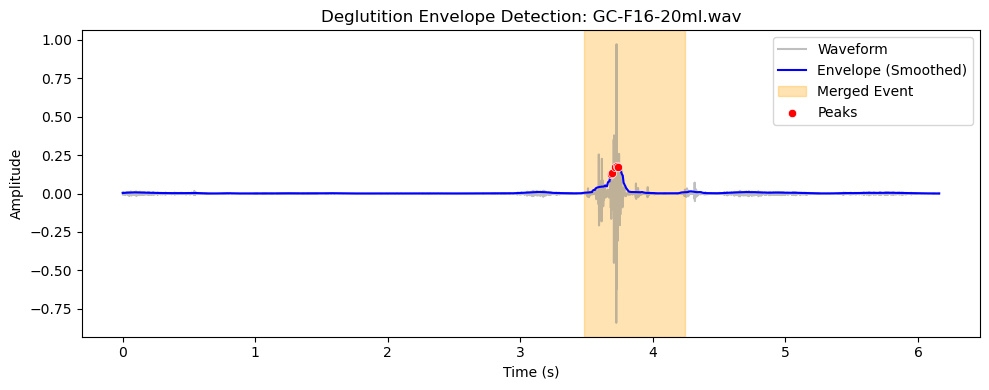

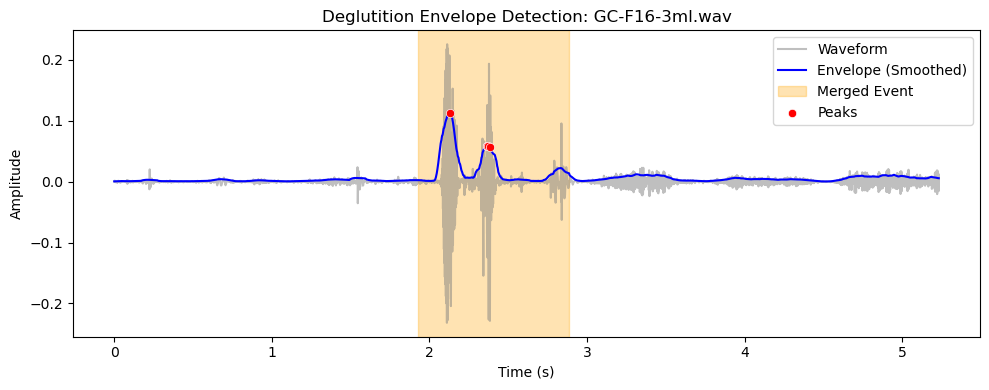

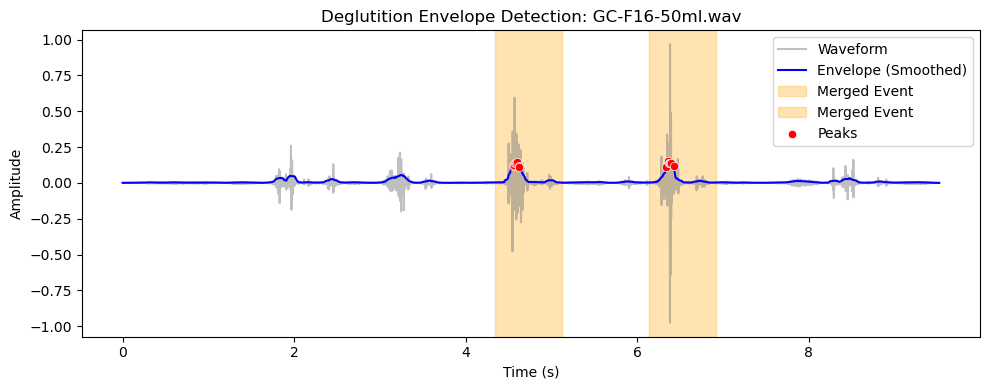

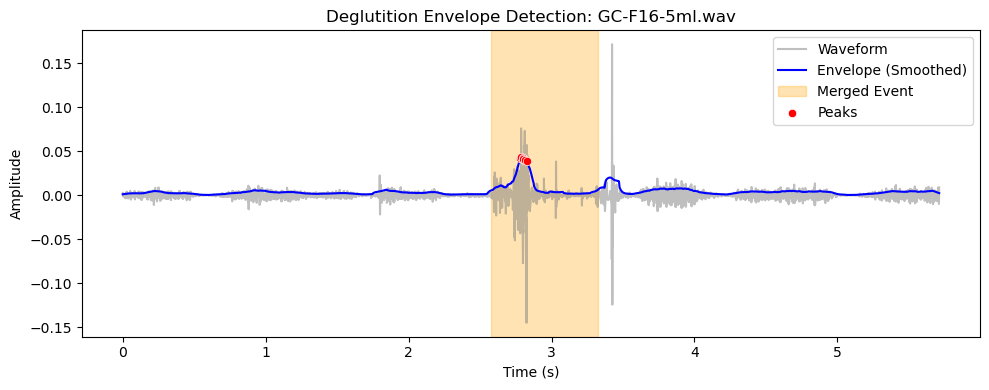

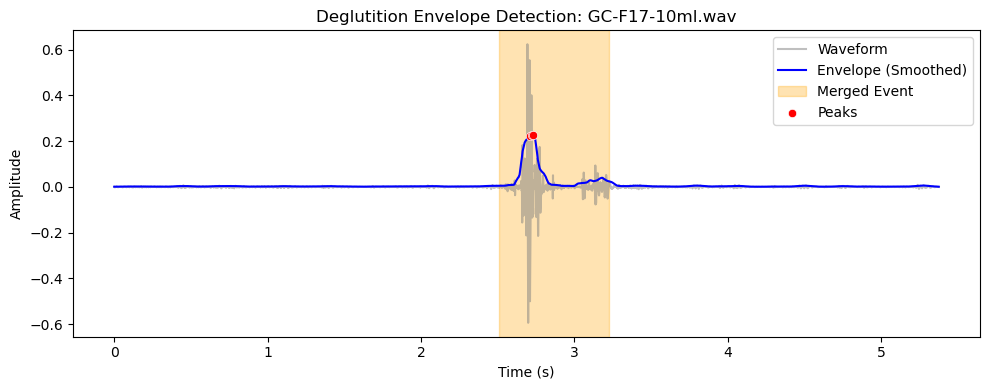

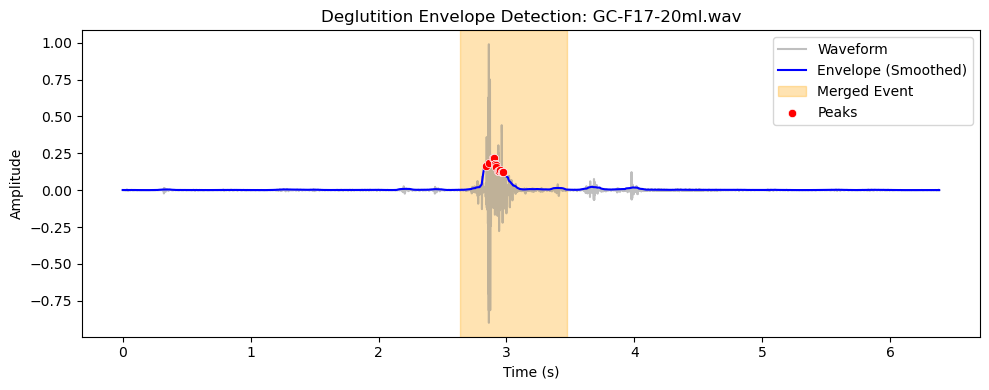

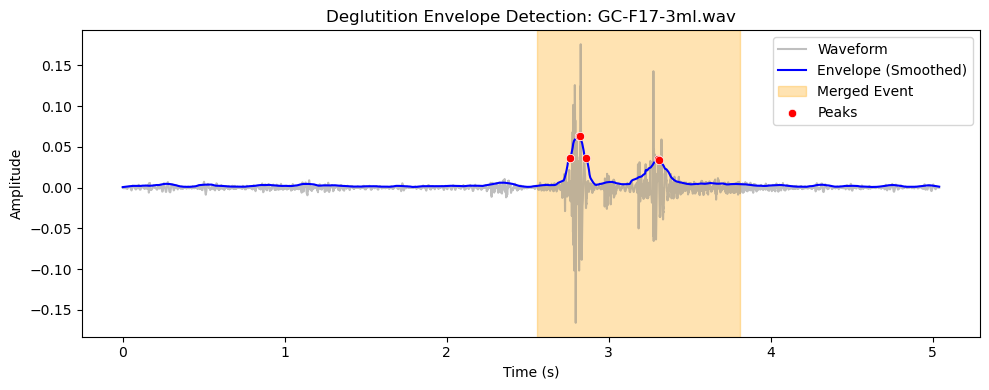

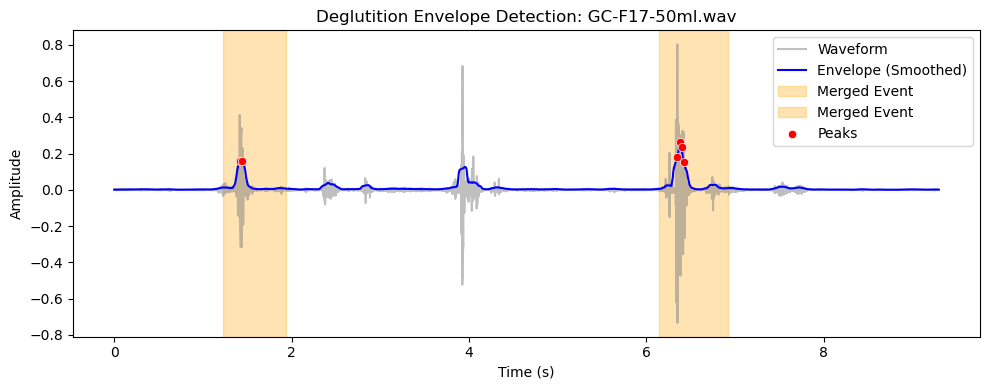

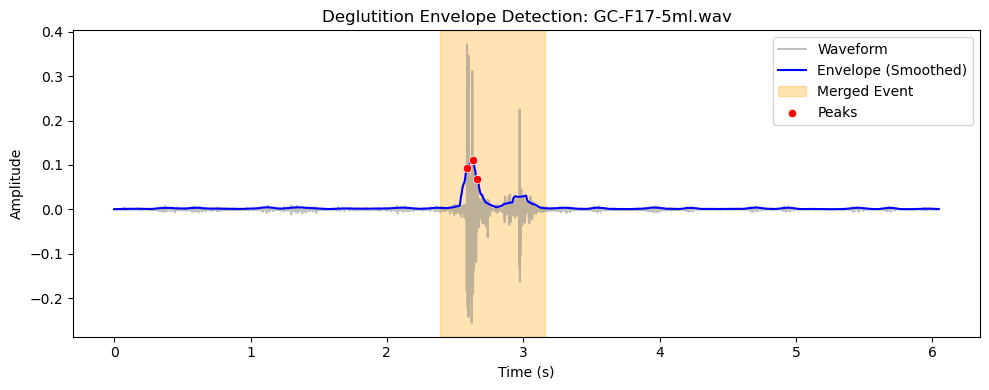

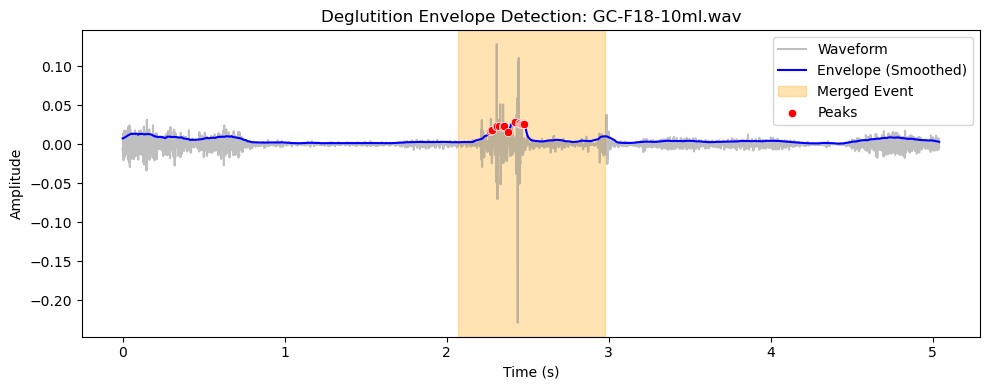

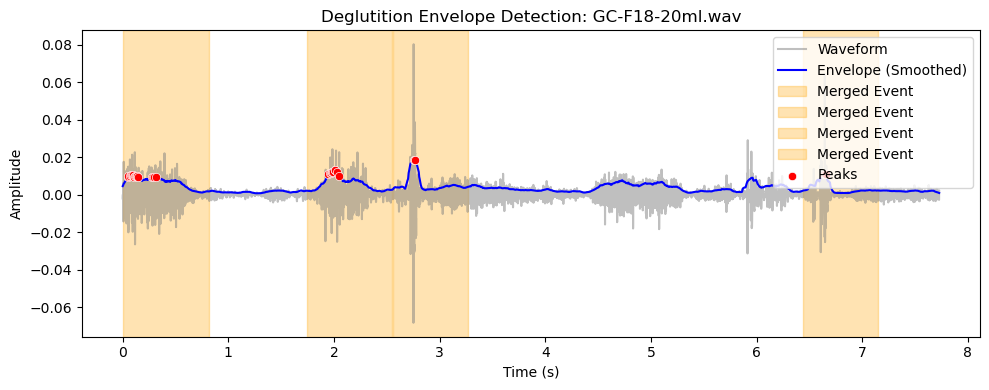

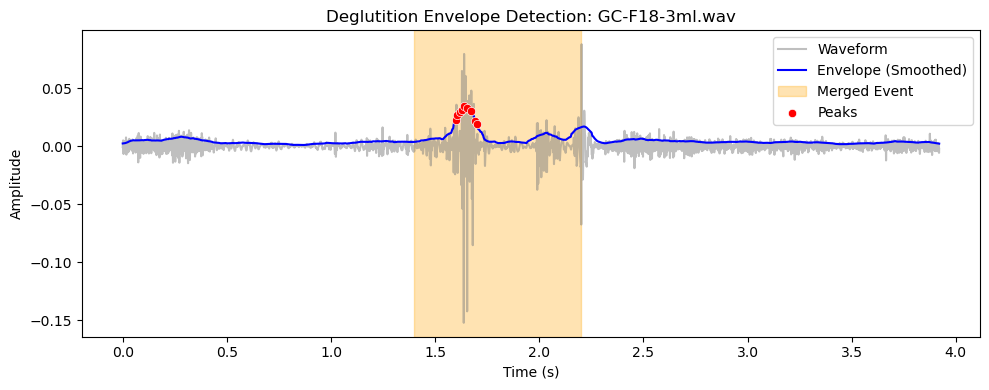

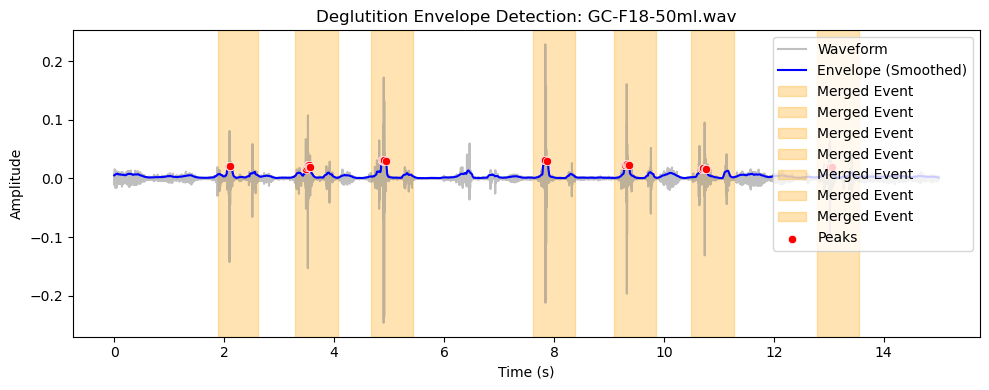

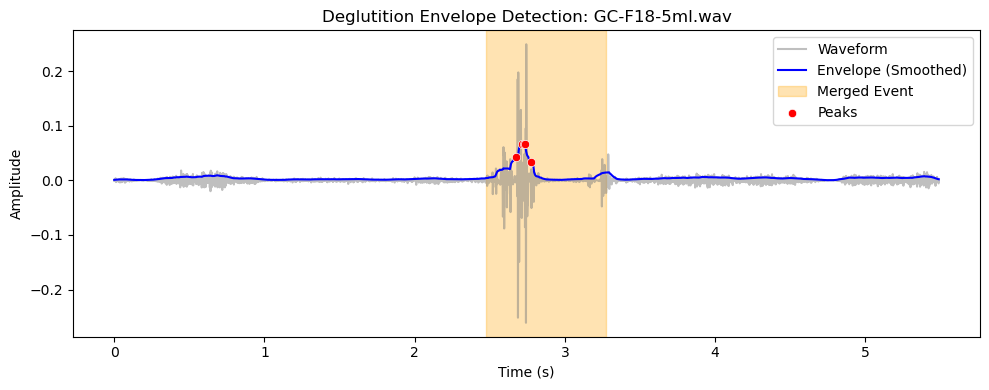

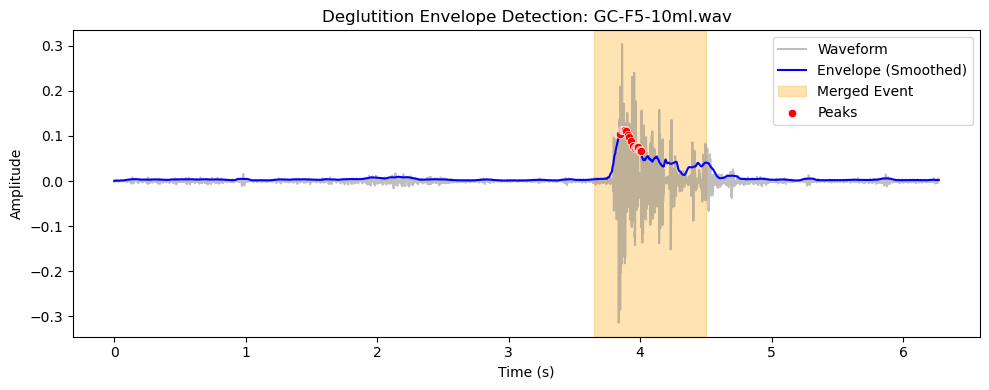

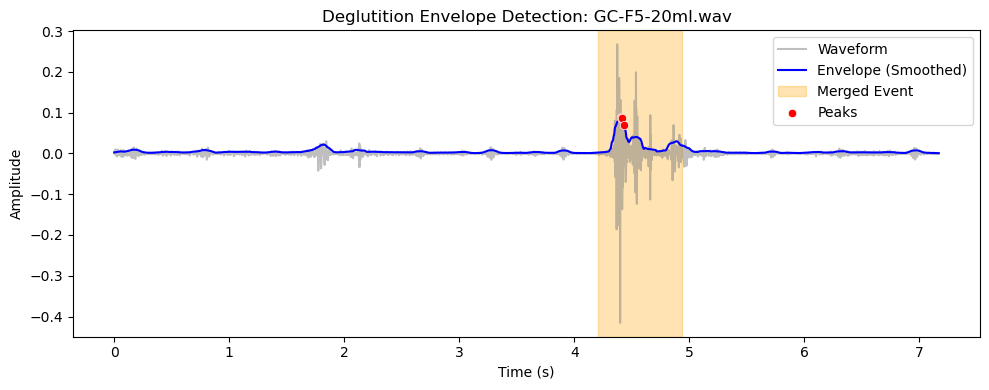

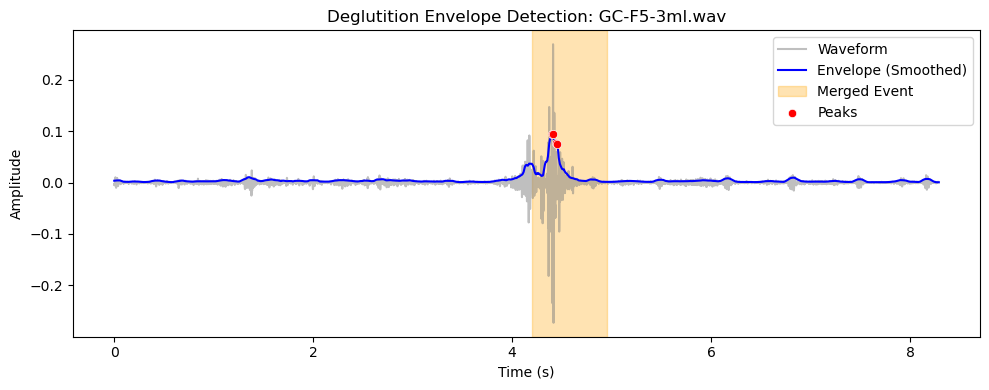

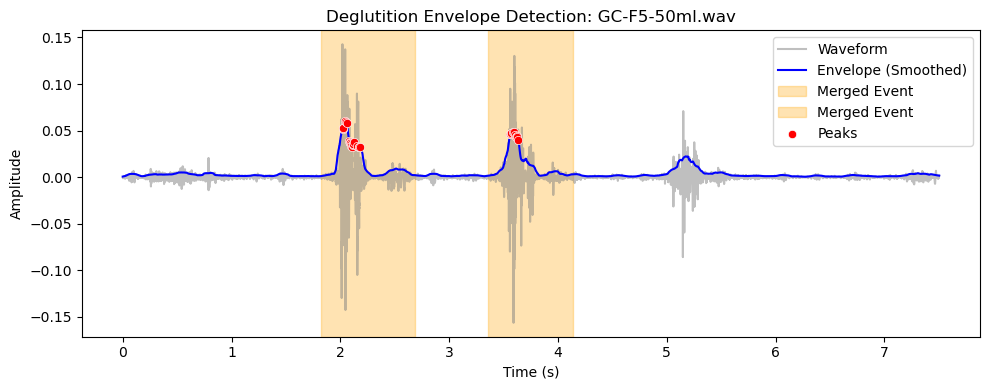

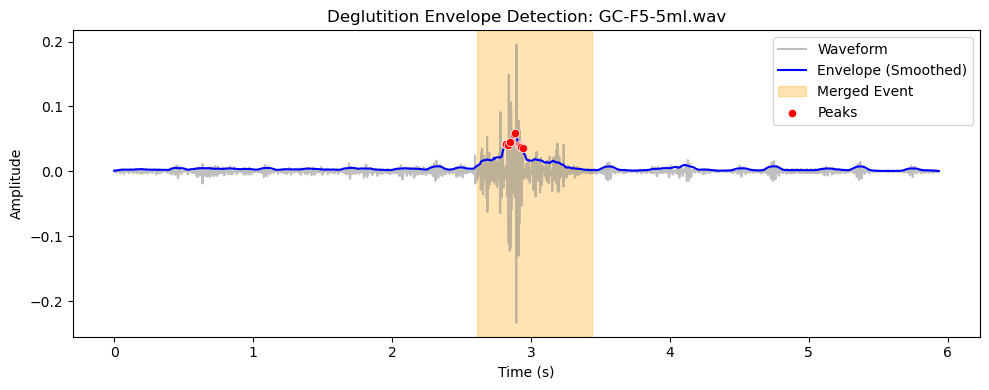

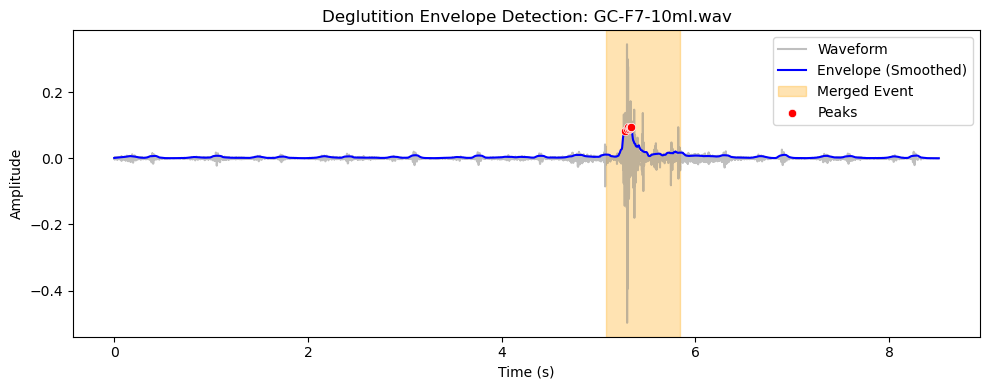

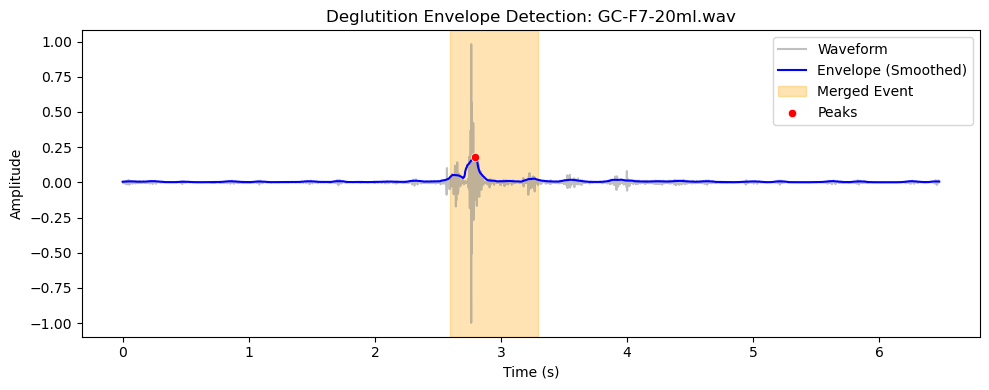

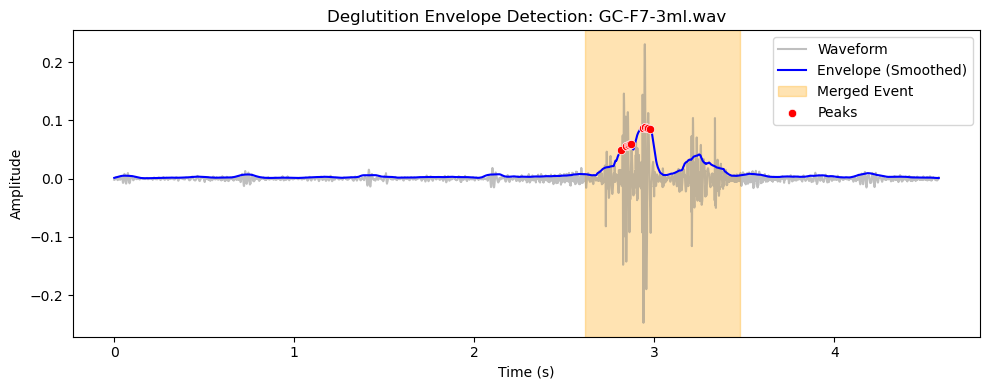

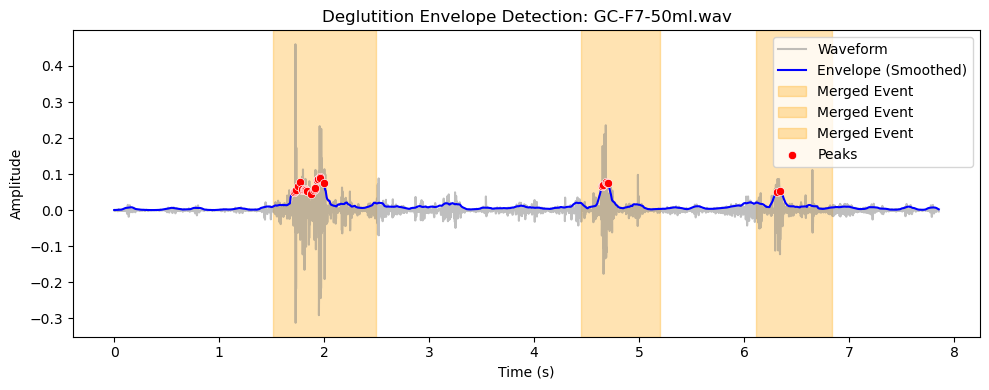

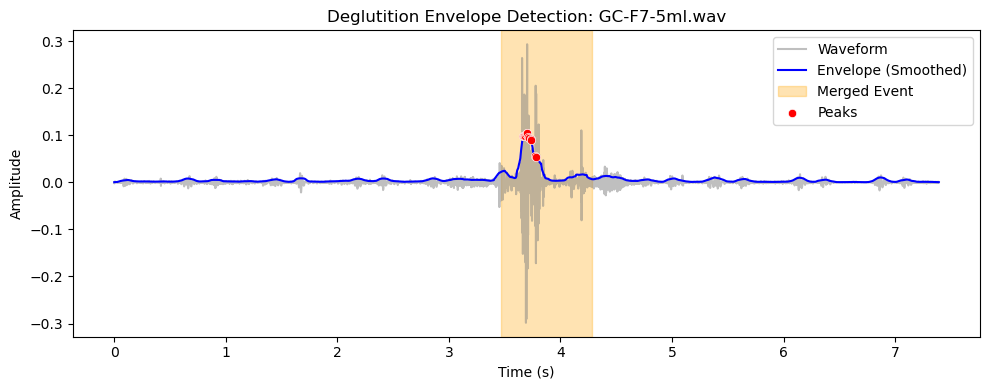

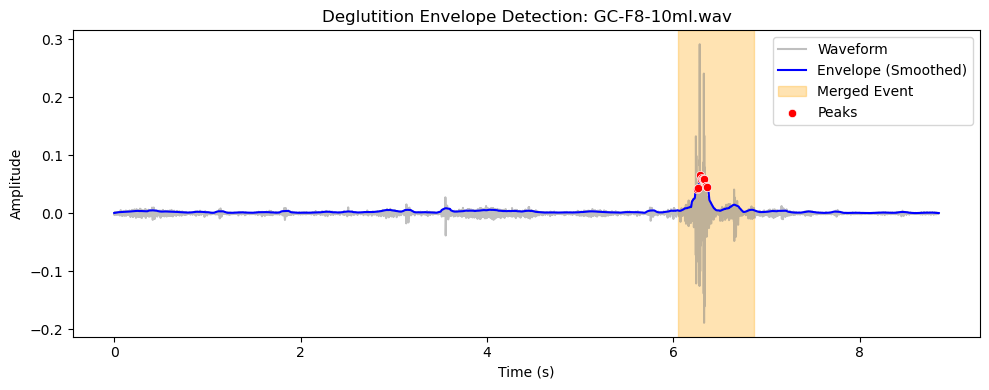

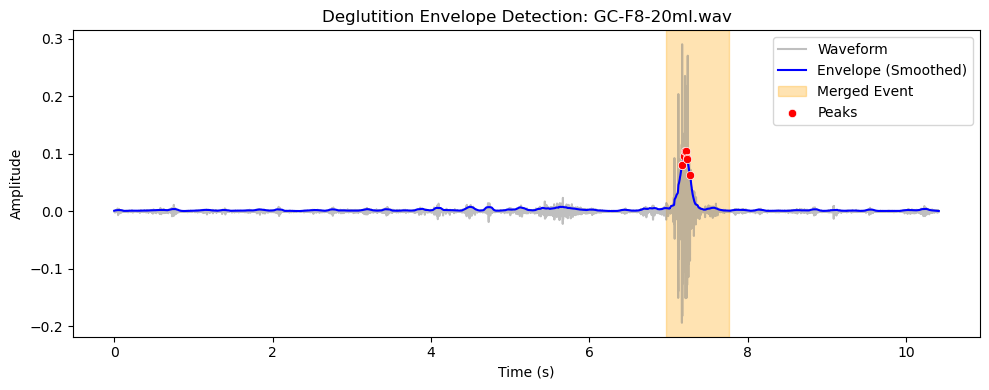

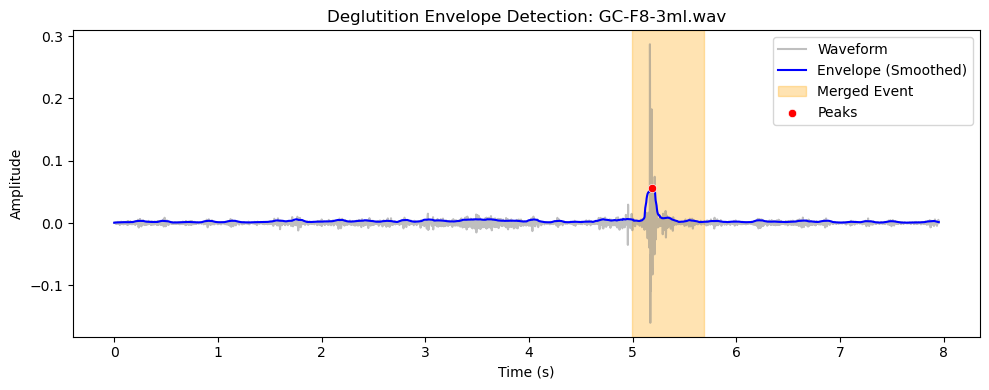

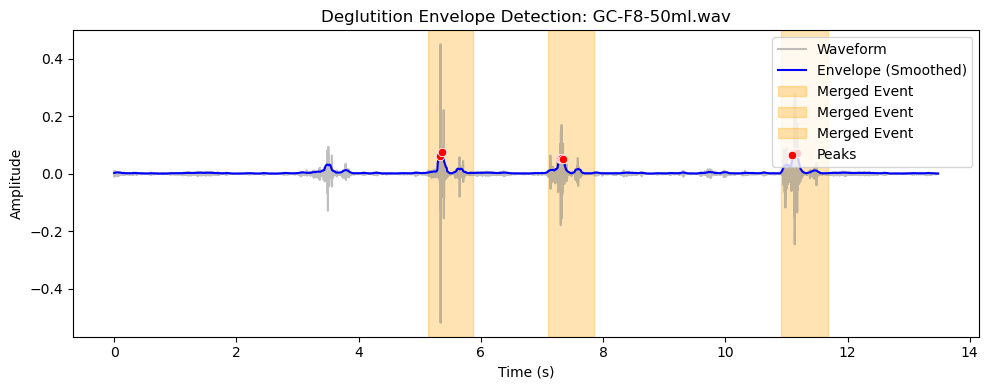

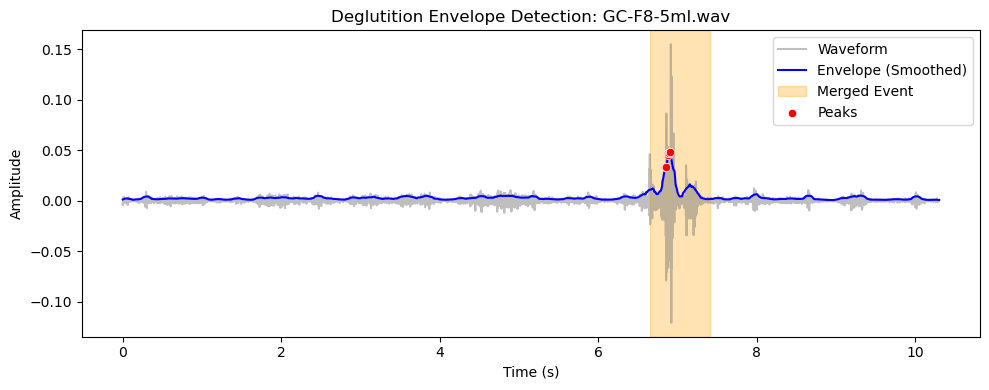

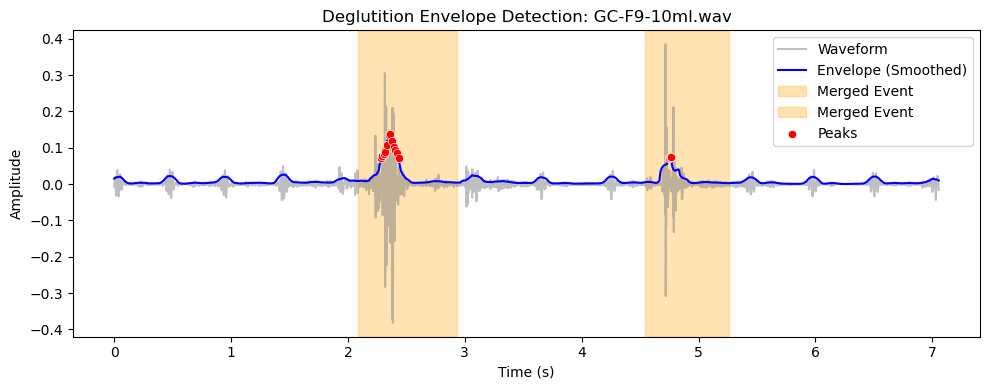

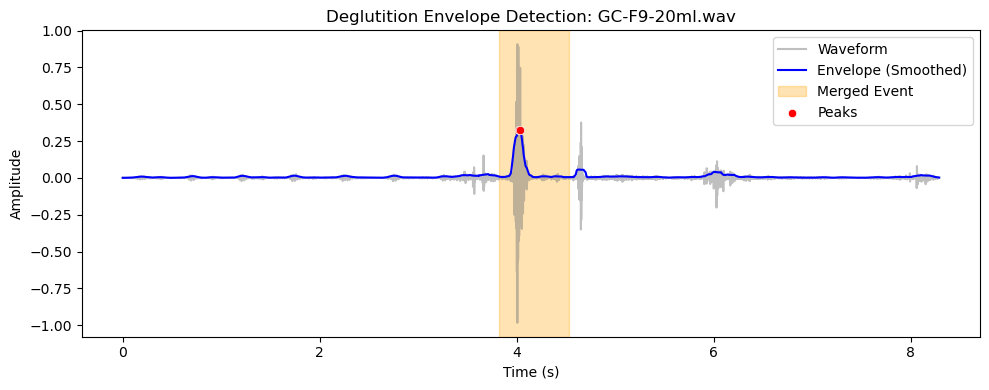

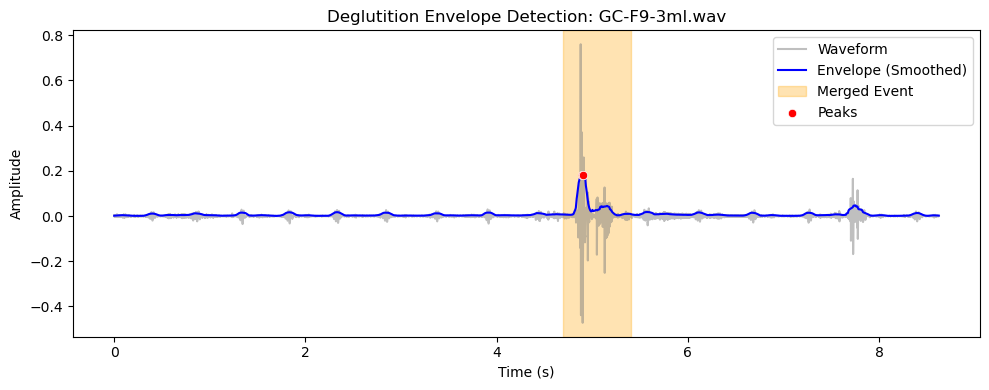

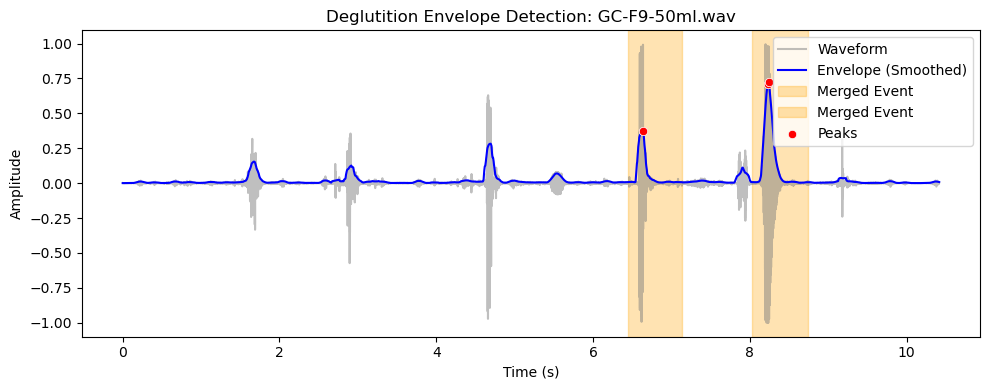

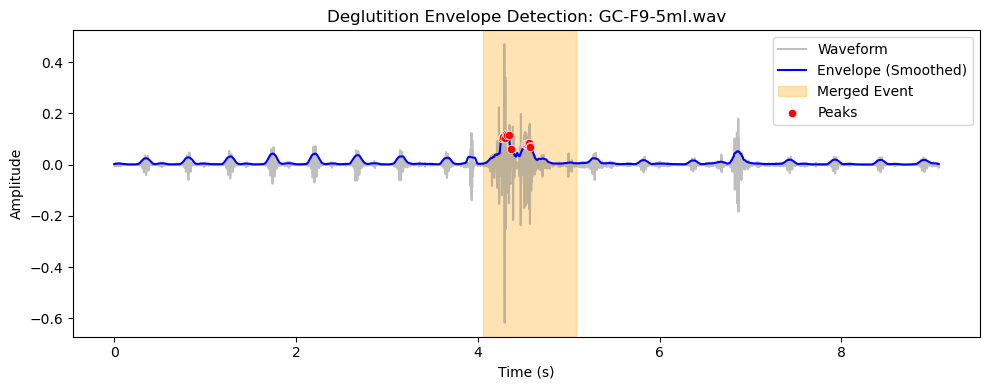

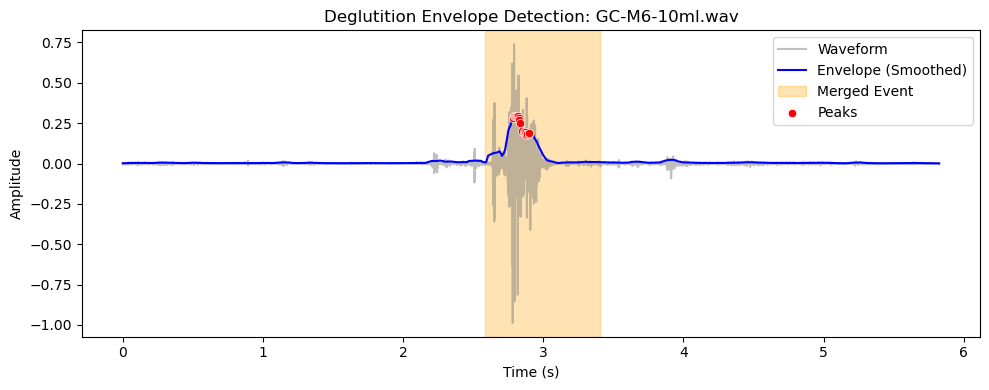

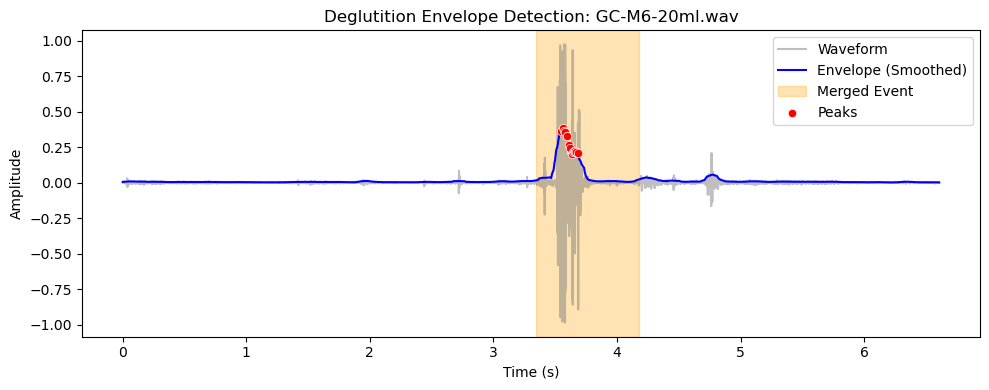

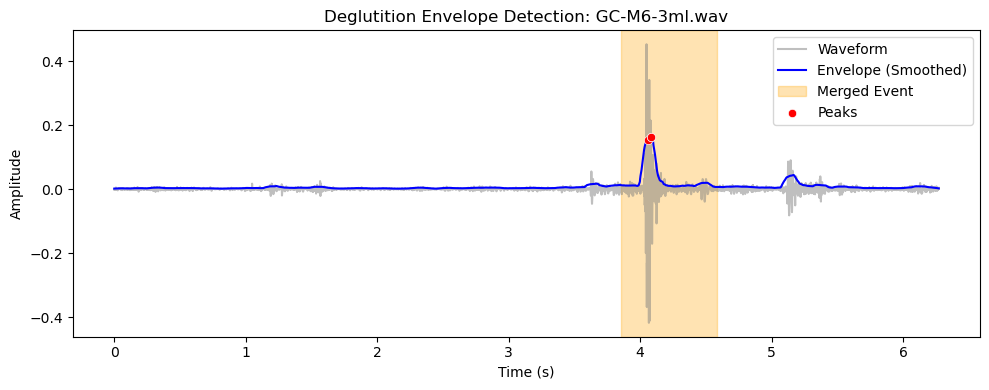

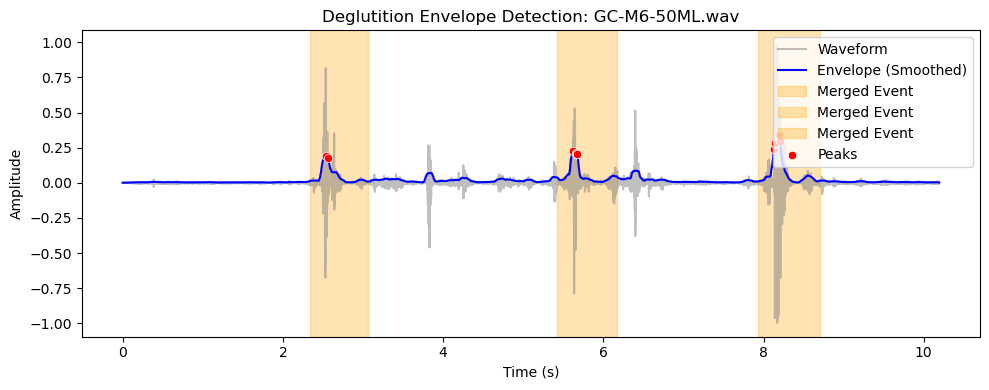

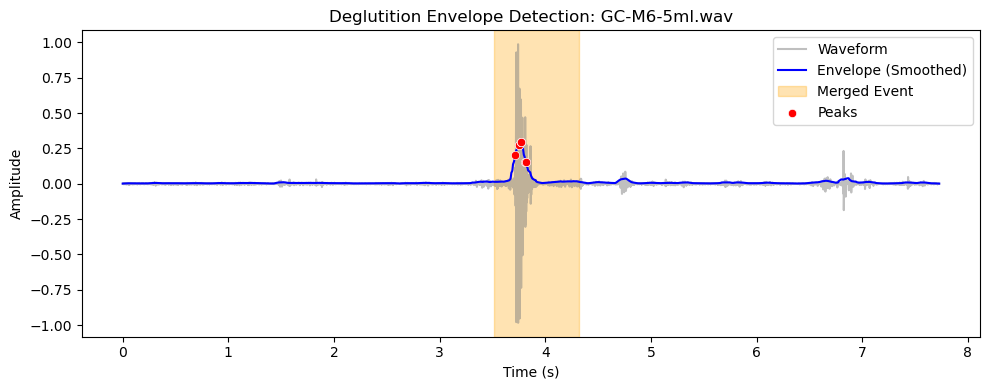

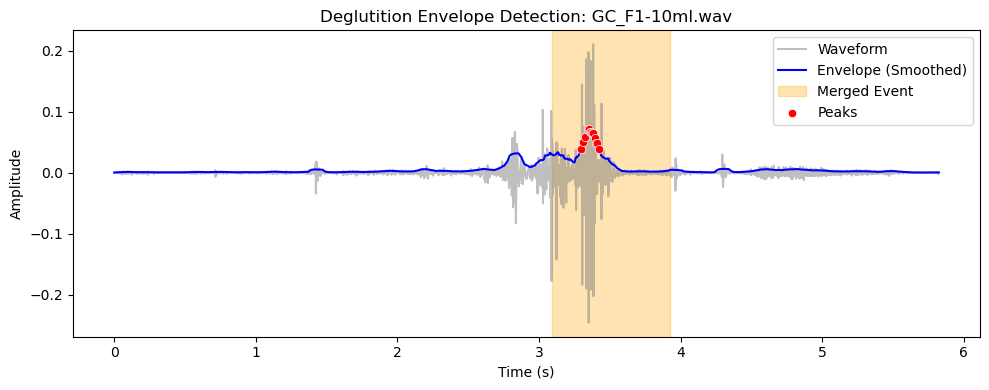

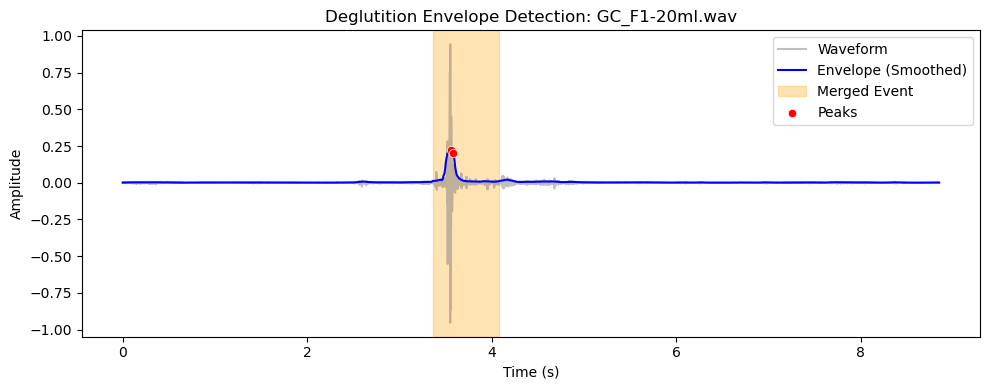

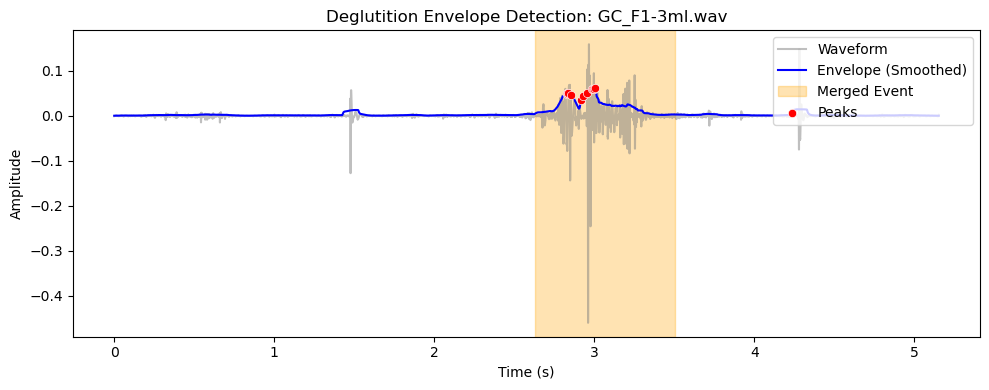

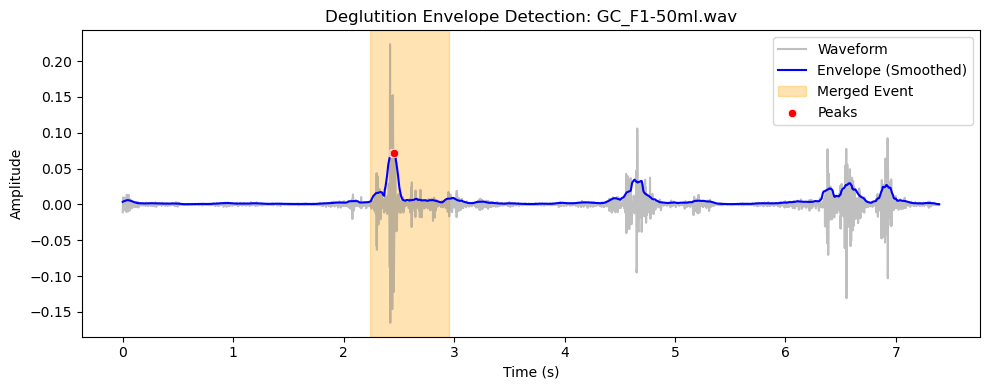

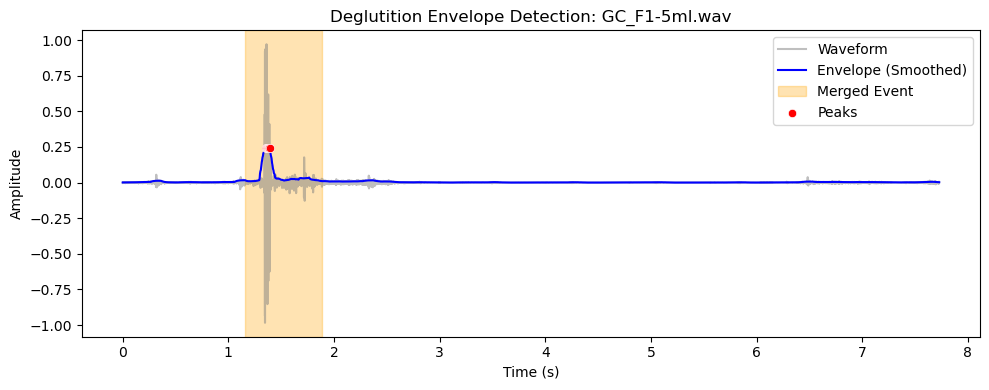

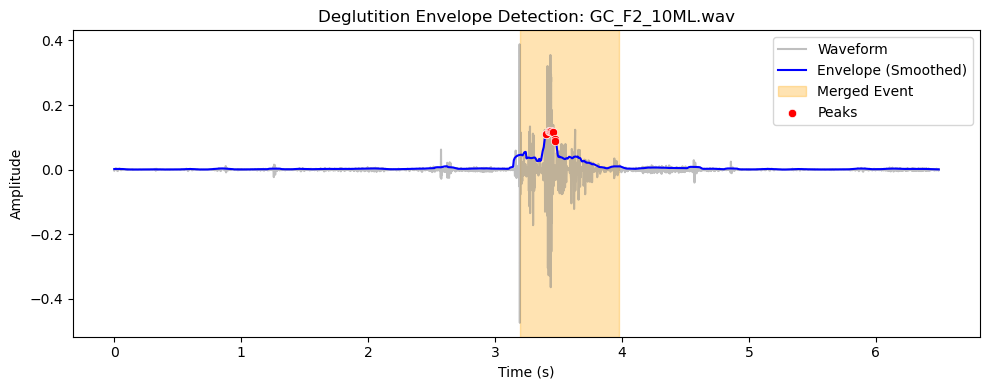

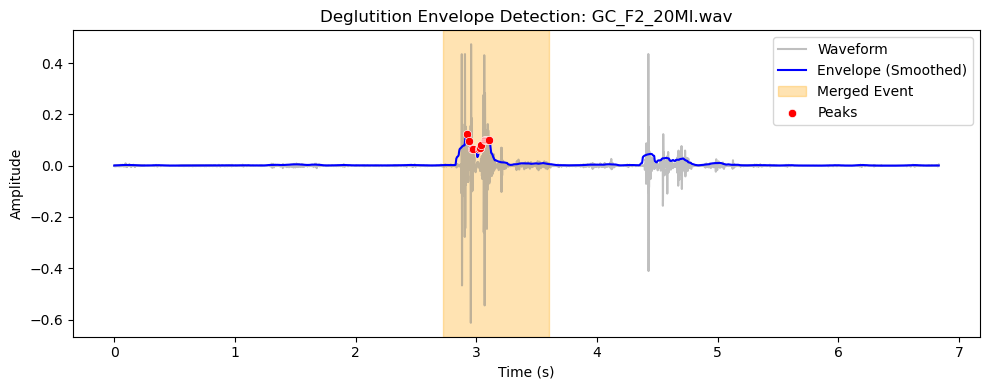

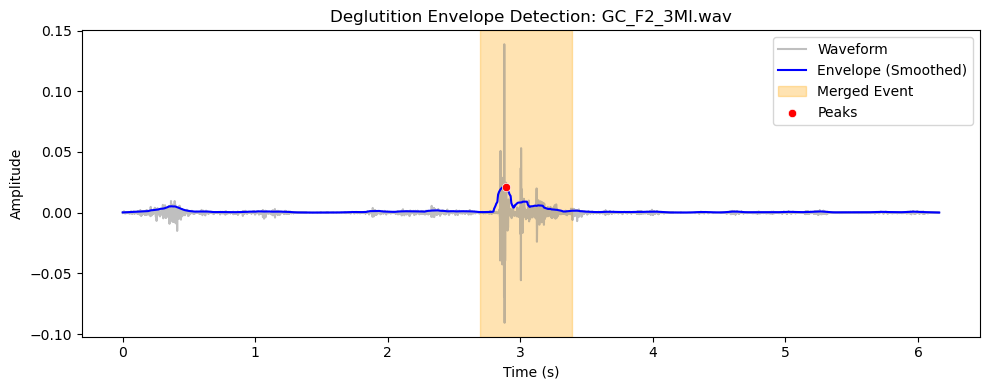

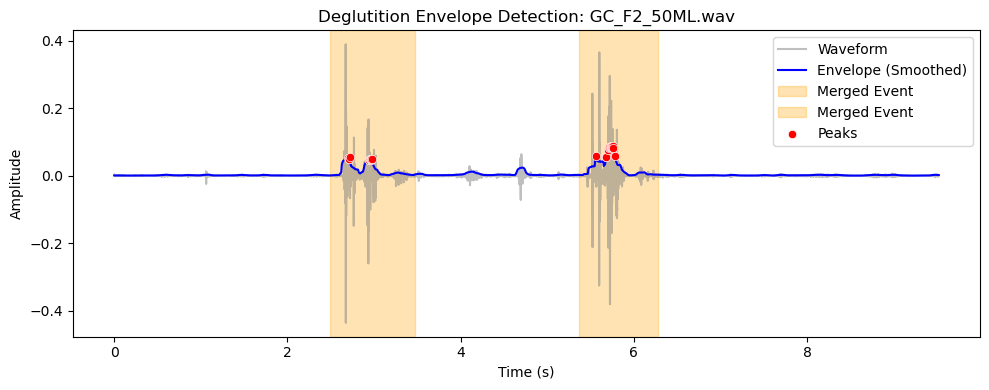

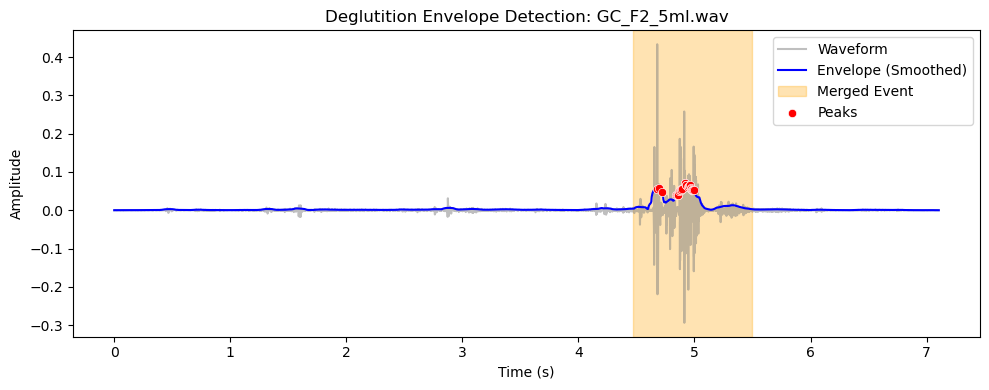

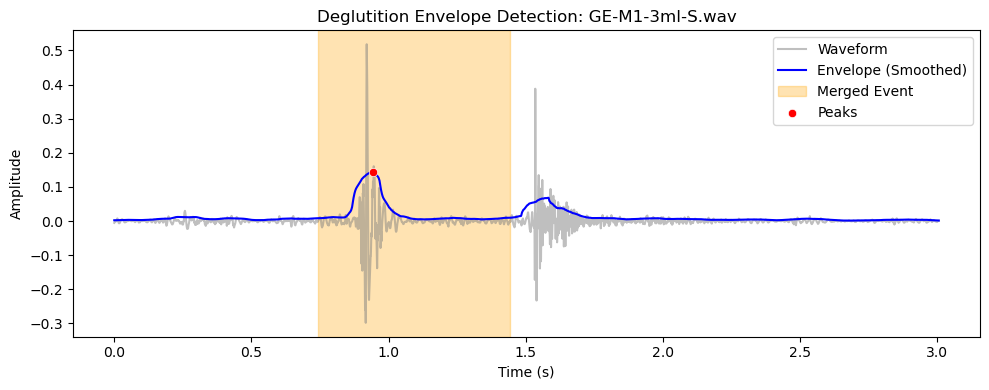

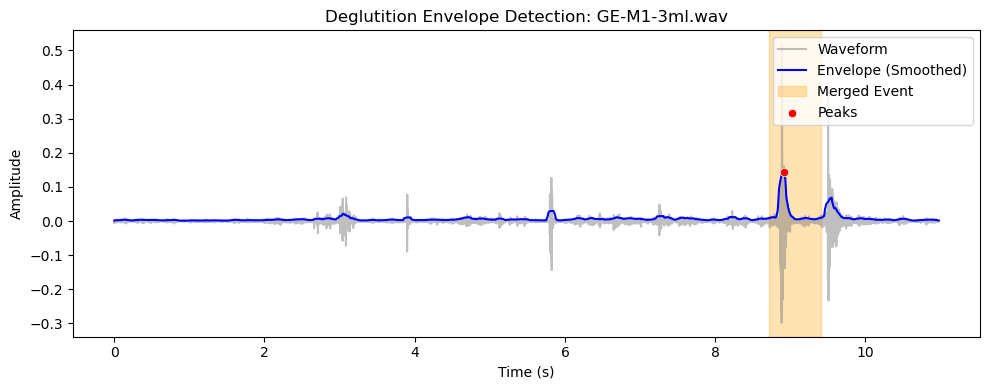

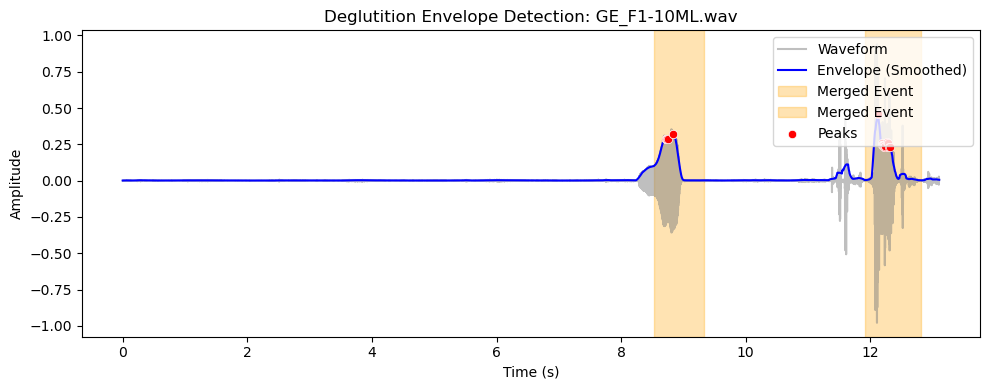

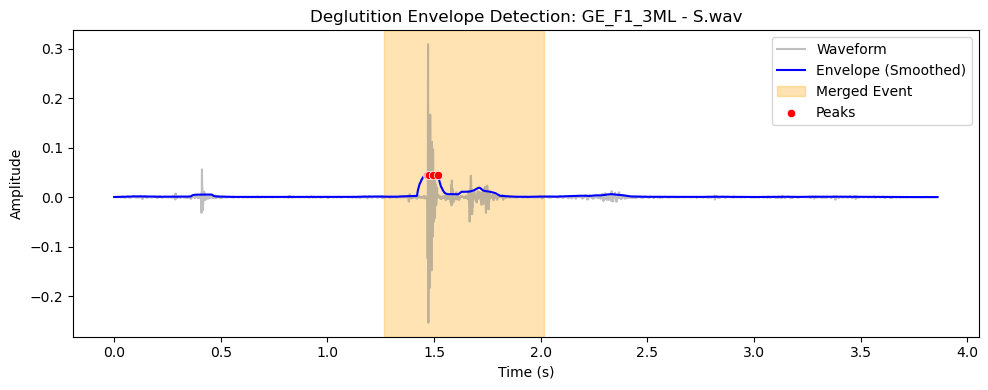

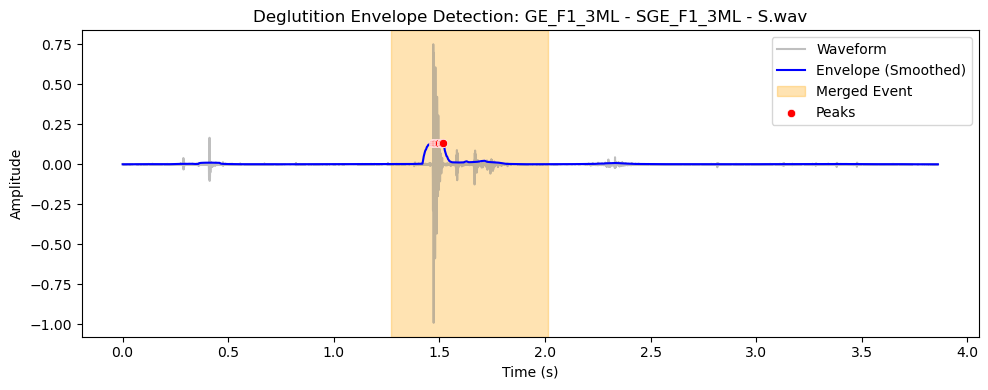

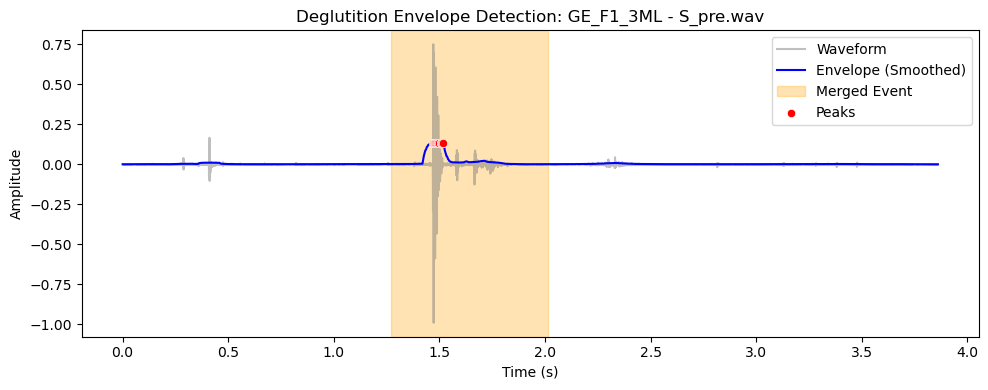

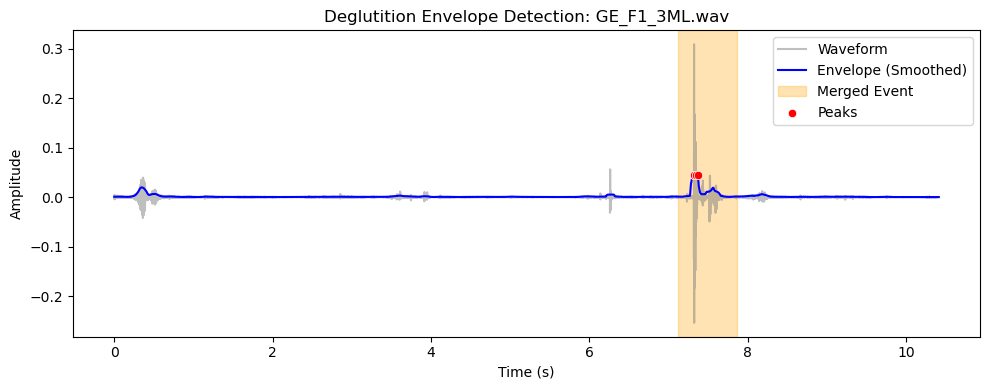

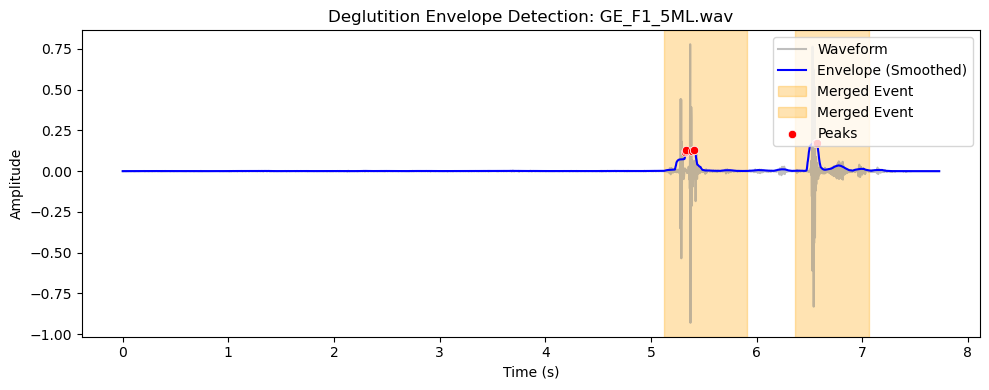

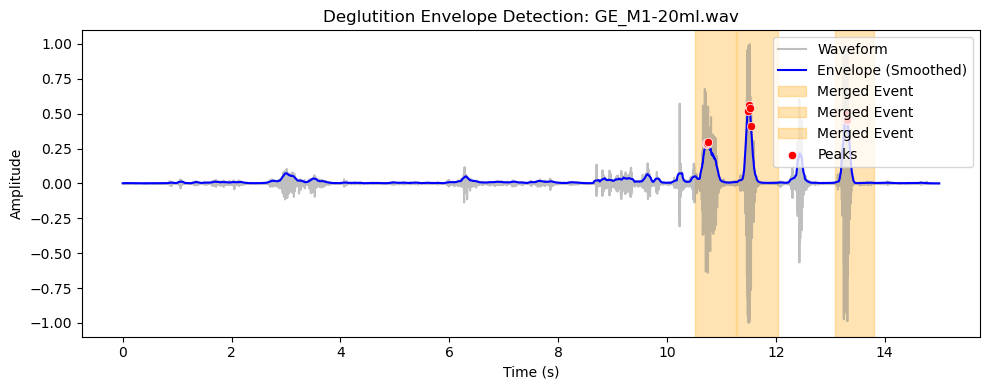

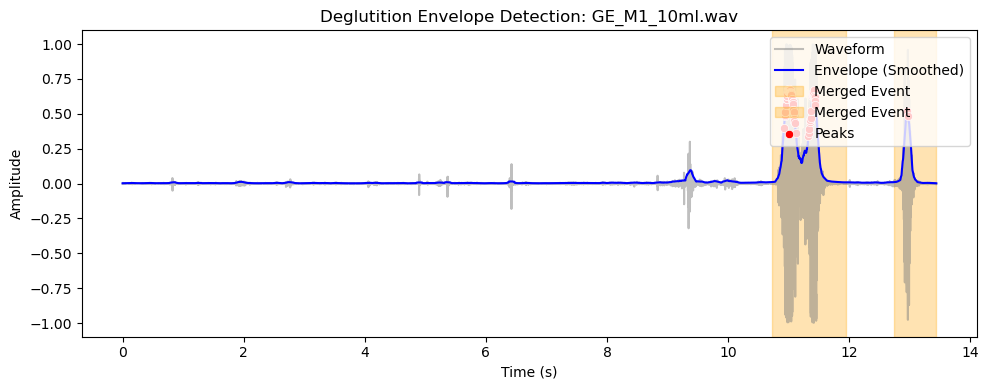

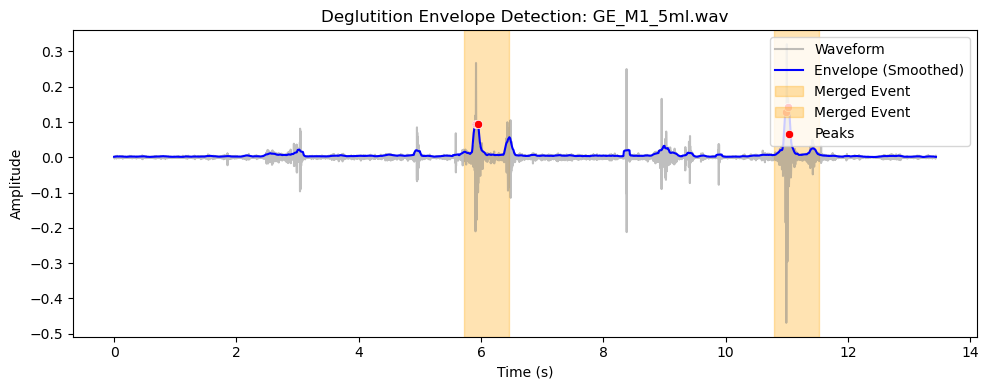

CSV file 'folder_deglutition_event_summary.csv' has been created with the extracted information.


In [3]:
def merge_intervals(intervals):
    """Merge overlapping intervals."""
    if not intervals:
        return intervals
    # Sort intervals by start time
    intervals.sort(key=lambda x: x[0])
    merged = [intervals[0]]
    for current in intervals[1:]:
        last = merged[-1]
        # If intervals overlap, merge them
        if current[0] <= last[1]:
            merged[-1] = (last[0], max(last[1], current[1]))
        else:
            merged.append(current)
    return merged

# Define the folder path containing the audio files
folder_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples"
audio_files = glob.glob(os.path.join(folder_path, "*.wav"))

results = []

# Process each audio file in the folder
for audio_file in audio_files:
    # Load audio and compute total duration
    y, sr = librosa.load(audio_file, sr=None)
    duration = len(y) / sr
    
    # Compute the amplitude envelope using the Hilbert transform
    analytic_signal = scipy.signal.hilbert(y)
    amplitude_envelope = np.abs(analytic_signal)
    
    # Smooth the envelope with a 100ms moving average filter
    window_size = int(sr * 0.1)
    smoothed_envelope = np.convolve(amplitude_envelope, np.ones(window_size)/window_size, mode='same')
    
    # Detect peaks in the smoothed envelope (using 50% of the max value as threshold)
    #peaks, _ = scipy.signal.find_peaks(smoothed_envelope, height=np.max(smoothed_envelope) * 0.5)
    peaks, _ = scipy.signal.find_peaks(smoothed_envelope, height=np.max(smoothed_envelope) * 0.5)
    peak_times = peaks / sr

    # Define events for each detected peak (200ms before to 500ms after the peak)
    events = []
    for pt in peak_times:
        event_start = max(0, pt - 0.2)
        event_end = min(duration, pt + 0.5)
        events.append((event_start, event_end))
    
    # Merge overlapping events
    merged_events = merge_intervals(events)
    num_events = len(merged_events)
    file_name = os.path.basename(audio_file)
    
    # Save event details with an extra column for event duration
    for (event_start, event_end) in merged_events:
        event_duration = event_end - event_start
        results.append({
            "File_Name": file_name,
            "Start_Time": event_start,
            "End_Time": event_end,
            "Event_Duration": event_duration,
            "Total_Duration": duration,
            "Number_of_Events": num_events
        })
    
    # (Optional) Plot for visualization using Seaborn
    plt.figure(figsize=(10, 4))
    time_axis = np.linspace(0, duration, len(y))
    
    # Create a DataFrame for seaborn-friendly plotting
    df_plot = pd.DataFrame({
        'Time (s)': time_axis,
        'Amplitude': y,
        'Smoothed Envelope': smoothed_envelope
    })
    
    # Plot the waveform and the smoothed envelope using Seaborn
    sns.lineplot(data=df_plot, x='Time (s)', y='Amplitude', alpha=0.5, label='Waveform', color='gray')
    sns.lineplot(data=df_plot, x='Time (s)', y='Smoothed Envelope', label='Envelope (Smoothed)', color='blue')
    
    # Highlight the merged events
    for (event_start, event_end) in merged_events:
        plt.axvspan(event_start, event_end, color='orange', alpha=0.3, label="Merged Event")
    
    # Highlight detected peaks
    sns.scatterplot(x=peak_times, y=smoothed_envelope[peaks], color='red', label='Peaks', zorder=5)
    
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"Deglutition Envelope Detection: {file_name}")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

# Combine all event information into a single DataFrame and save as one CSV file
df_results = pd.DataFrame(results)
df_results.to_csv("folder_deglutition_event_summary.csv", index=False)

print("CSV file 'folder_deglutition_event_summary.csv' has been created with the extracted information.")